# Aim of Notebook: AO3 Canonical Tag Co-occurrence Network Analysis

Given the scale and diversity of the corpus, a single tag co-occurrence network would have limited interpretive value. This notebook therefore constructs separate networks for the most frequent and distinctive canonical AO3 tags across four rating categories in BTS Reader-Insert fanfiction: General Audiences, Teen and Up Audiences, Mature, and Explicit.

Louvain and Leiden community detection algorithms are tested across different parameter settings to identify groups of frequently co-occurring tags.

BTS member-specific tags are additionally incorporated to examine how these co-occurrence patterns contribute to member-specific characterizations and archetypes. Model selection combines quantitative measures of network structure and stability with qualitative interpretation of whether the detected communities correspond to recognizable fanfiction conventions.

# Table of Contents

## 1. Setting Up Notebook Enviroment

In [1]:
# System utilities
from pathlib import Path
from collections import Counter
from itertools import combinations
import ast
import sys 
import os 
import re
import json
from collections import defaultdict


# Data handling
import pandas as pd
import numpy as np
from sklearn.metrics import adjusted_rand_score

# Network analysis
import networkx as nx
import igraph as ig
import leidenalg
import community.community_louvain as community_louvain

# Visualization / display
from IPython.display import display


import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML
from wordcloud import WordCloud
from plotly.subplots import make_subplots

from fa2 import ForceAtlas2
from matplotlib.colors import hex2color


D:\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
D:\anaconda3\Lib\site-packages\fa2\forceatlas2.py:25: UserWarning: Running pure Python fa2util (no compiled extension found). Rebuild for 10-100x speedup: pip install cython && pip install --no-build-isolation fa2
  from . import fa2util


In [2]:
# Project paths

PROJECT_ROOT = Path().resolve().parent

NOTEBOOKS_PATH = PROJECT_ROOT / "notebooks"
SCRIPTS_PATH = PROJECT_ROOT / "scripts"

DATA_DIR = PROJECT_ROOT / "data"

CLEAN_DIR = DATA_DIR / "cleaned"
CLEAN_FICS_PATH = CLEAN_DIR / "fics"

REPORTS_PATH = PROJECT_ROOT / "reports"
FICS_REPORTS_PATH = REPORTS_PATH / "fics_reports"
FICS_FIGURES_PATH = REPORTS_PATH / "fics_figures"


# Output directory for network results

RESULTS_DIR = FICS_REPORTS_PATH / "tag_network_models"



# Create project directories if they do not exist

for path in [
    NOTEBOOKS_PATH,
    SCRIPTS_PATH,
    DATA_DIR,
    CLEAN_DIR,
    CLEAN_FICS_PATH,
    REPORTS_PATH,
    FICS_REPORTS_PATH,
    FICS_FIGURES_PATH,
    RESULTS_DIR
]:
    path.mkdir(
        parents=True,
        exist_ok=True
    )


# Check project structure

print("Project root is:", PROJECT_ROOT)
print("Notebooks folder exists:", NOTEBOOKS_PATH.exists())
print("Scripts folder exists:", SCRIPTS_PATH.exists())
print("Data folder exists:", DATA_DIR.exists())
print("Cleaned data folder exists:", CLEAN_DIR.exists())
print("Cleaned fics folder exists:", CLEAN_FICS_PATH.exists())
print("Reports folder exists:", REPORTS_PATH.exists())
print("Fics reports folder exists:", FICS_REPORTS_PATH.exists())
print("Fics figures folder exists:", FICS_FIGURES_PATH.exists())
print("Network results folder exists:", RESULTS_DIR.exists())

Project root is: E:\Jupyter_Programs\DH_Thesis
Notebooks folder exists: True
Scripts folder exists: True
Data folder exists: True
Cleaned data folder exists: True
Cleaned fics folder exists: True
Reports folder exists: True
Fics reports folder exists: True
Fics figures folder exists: True
Network results folder exists: True


## 2. Load the Cleaned Dataset and Contextual Visualizations

This section loads the cleaned BTS reader-insert fanfiction corpus used for the tag co-occurrence network analysis. The dataset contains preprocessed metadata of fan-created tags that are AO3 canonical tag categories used in the following analysis. Certain contextual visualizations are created here that situate the analysis across ratings better.

### 2.1 Load Dataset 

In [3]:
#load dataset

def load_file(file_path):
    """Load fic metadata dataset."""
    return pd.read_csv(file_path)


fics = load_file(
    CLEAN_FICS_PATH / "bts_all_member_fics_masked.csv"
)

print("Dataset shape:", fics.shape)


Dataset shape: (6668, 17)


In [4]:
dataset_summary = pd.DataFrame({
    "Metric": ["Total Records", "Total Columns"],
    "Value": [fics.shape[0], fics.shape[1]]
})

display(dataset_summary)

,Metric,Value
0,Total Records,6668
1,Total Columns,17


In [5]:
fics.columns

Index(['s', 'title', 'summary', 'datePublished', 'words', 'rating',
       'romanticCategory', 'publicationStatus', 'kudos', 'member', 'keyword',
       'relationship', 'tag_list', 'canonical_tags', 'noncanonical_tags',
       'filtered_noncanonical_tags', 'bts_tags'],
      dtype='str')

### 2.2 Rating × Romantic Category Distribution

This visualization examines the distribution of BTS reader-insert fanfiction across **content ratings** and the three primary romantic categories: **F/F, F/M, and M/M**.

The counts are grouped by rating category and romantic category to compare how the composition of the corpus varies across different content-rating levels. A **logarithmic y-axis** is used to make differences visible across categories with substantially different numbers of works.

Only **F/F, F/M, and M/M** works are included, allowing the comparison to focus specifically on these romantic relationship categories.

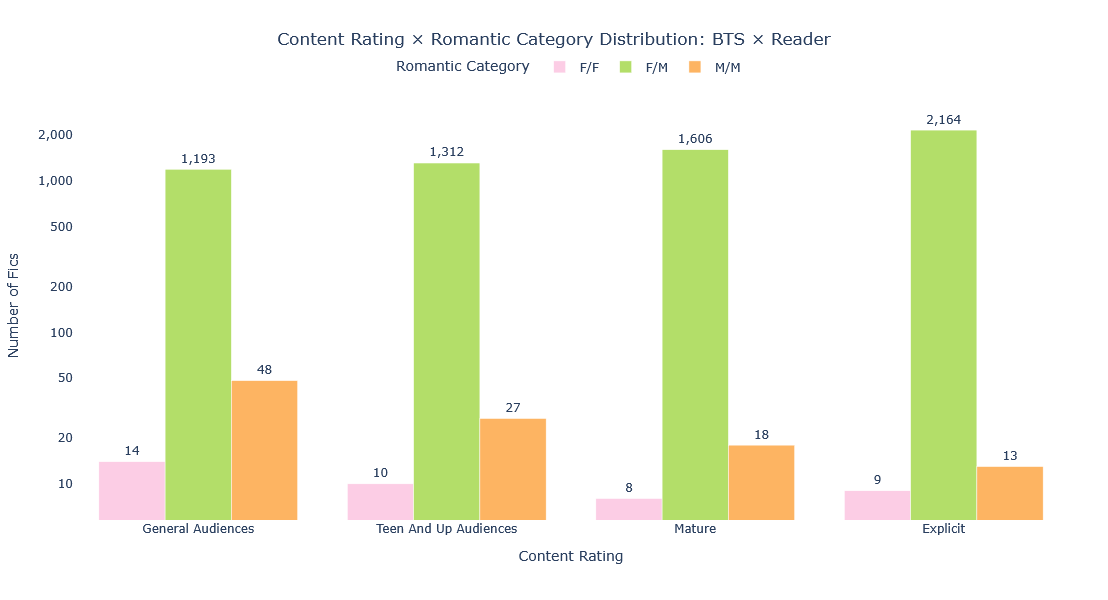

PNG already exists. Skipping.
HTML already exists. Skipping.


In [6]:
# Rating × Romantic Category counts
# Only F/F, F/M, M/M

selected_categories = [
    "F/F",
    "F/M",
    "M/M"
]

rating_category_counts = (
    fics[
        fics["romanticCategory"].isin(selected_categories)
    ]
    .groupby(["rating", "romanticCategory"])
    .size()
    .reset_index(name="Count")
)

# Keep the same rating ordering as before

rating_order = (
    fics["rating"]
    .value_counts()
    .sort_values()
    .index
    .tolist()
)

rating_category_counts["rating"] = pd.Categorical(
    rating_category_counts["rating"],
    categories=rating_order,
    ordered=True
)

rating_category_counts = (
    rating_category_counts
    .sort_values(["rating", "Count"])
)

# Consistent colors

category_color_map = {
    "F/F": "#fccde5",
    "F/M": "#b3de69",
    "M/M": "#fdb462"
}

# Plot

fig = go.Figure()

for category in selected_categories:

    category_df = rating_category_counts[
        rating_category_counts["romanticCategory"] == category
    ]

    # Reindex so every category has a position for every rating
    category_df = (
        category_df
        .set_index("rating")
        .reindex(rating_order)
        .reset_index()
    )

    category_df["Count"] = category_df["Count"].fillna(0)

    fig.add_trace(
        go.Bar(
            x=category_df["rating"],
            y=category_df["Count"],
            name=category,
            marker=dict(
                color=category_color_map[category]
            ),
            text=[
                f"{int(x):,}" if x > 0 else ""
                for x in category_df["Count"]
            ],
            textposition="outside",
            hovertemplate=(
                "<b>Rating:</b> %{x}"
                "<br><b>Category:</b> " + category +
                "<br><b>Fics:</b> %{y:,}"
                "<extra></extra>"
            )
        )
    )


fig.update_layout(
    template="plotly_white",

    title=dict(
        text="Content Rating × Romantic Category Distribution: BTS × Reader",
        x=0.5
    ),

    width=1000,
    height=600,

    margin=dict(
        l=70,
        r=40,
        t=90,
        b=80
    ),

    font=dict(size=12),

    barmode="group",

    legend=dict(
        title="Romantic Category",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    )
)

fig.update_xaxes(
    showgrid=False,
    showline=False,
    title="Content Rating",
    categoryorder="array",
    categoryarray=rating_order
)

fig.update_yaxes(
    showgrid=False,
    showline=False,
    title="Number of Fics",
    type="log",
    tickvals=[
        1,
        2,
        5,
        10,
        20,
        50,
        100,
        200,
        500,
        1000,
        2000,
        5000
    ],
    ticktext=[
        "1",
        "2",
        "5",
        "10",
        "20",
        "50",
        "100",
        "200",
        "500",
        "1,000",
        "2,000",
        "3,000"
    ]
)

fig.show()

png_file = (
    FICS_FIGURES_PATH /
    "09_fics_romantic_category.png"
)

html_file = (
    FICS_FIGURES_PATH /
    "09_fics_romantic_category.html"
)


if not png_file.exists():

    fig.write_image(
        png_file,
        width=1000,
        height=600,
        scale=2
    )

    print(
        f"Saved PNG: {png_file}"
    )

else:

    print(
        "PNG already exists. Skipping."
    )


if not html_file.exists():

    fig.write_html(
        html_file
    )

    print(
        f"Saved HTML: {html_file}"
    )

else:

    print(
        "HTML already exists. Skipping."
    )

### 2.3 Fic Distribution Across Ratings

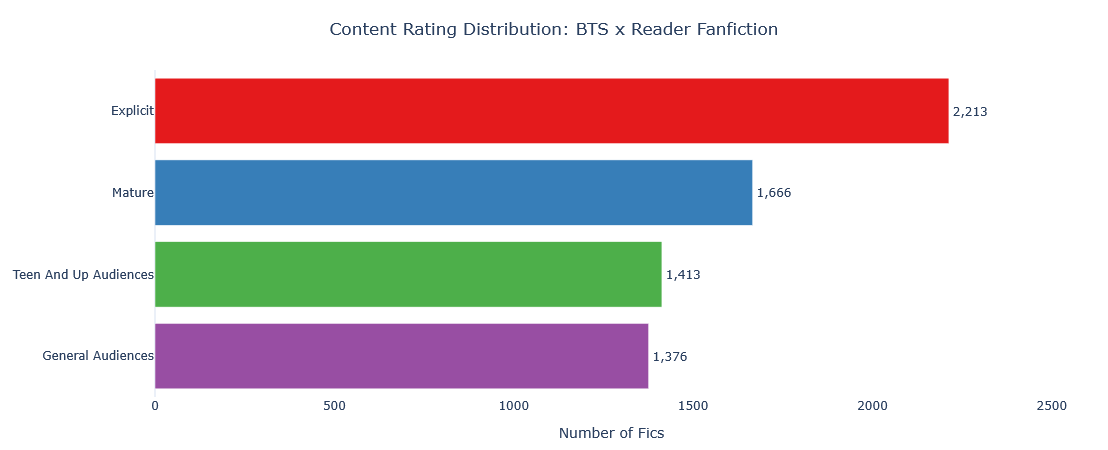

PNG already exists. Skipping.
HTML already exists. Skipping.


In [7]:
rating_counts = (
    fics["rating"]
    .value_counts()
    .reset_index()
)

rating_counts.columns = ["Rating", "Count"]

rating_counts = rating_counts.sort_values(
    "Count",
    ascending=True
)

rating_colors = [
    "#984ea3",
    "#4daf4a",
    "#377eb8",
    "#e41a1c",
]


fig = go.Figure(
    go.Bar(
        y=rating_counts["Rating"],
        x=rating_counts["Count"],
        orientation="h",
        marker=dict(
            color=rating_colors[:len(rating_counts)]
        ),
        text=[
            f"{x:,}"
            for x in rating_counts["Count"]
        ],
        textposition="outside",
        hovertemplate="%{y}<br>%{x:,} fics<extra></extra>",
    )
)

fig.update_layout(
    template="plotly_white",
    title=dict(
        text="Content Rating Distribution: BTS x Reader Fanfiction",
        x=0.5
    ),
    width=700,
    height=450,
    margin=dict(
        l=140,
        r=40,
        t=70,
        b=50
    ),
    font=dict(size=12)
)

fig.update_xaxes(
    showgrid=False,
    showline=False,
    title="Number of Fics",
    range=[0, max(rating_counts["Count"]) + max(rating_counts["Count"])*0.15]
)

fig.update_yaxes(
    showgrid=False,
    showline=False,
    categoryorder="array",
    categoryarray=rating_counts["Rating"]
)

fig.show()

png_file = (
    FICS_FIGURES_PATH /
    "10_rating_distribution.png"
)

html_file = (
    FICS_FIGURES_PATH /
    "10_rating_distribution.html"
)


if not png_file.exists():

    fig.write_image(
        png_file,
        width=700,
        height=450,
        scale=2
    )

    print(
        f"Saved PNG: {png_file}"
    )

else:

    print("PNG already exists. Skipping.")


if not html_file.exists():

    fig.write_html(
        html_file
    )

    print(
        f"Saved HTML: {html_file}"
    )

else:

    print("HTML already exists. Skipping.")

### 2.4 Distribution of Fics by BTS Member x Rating

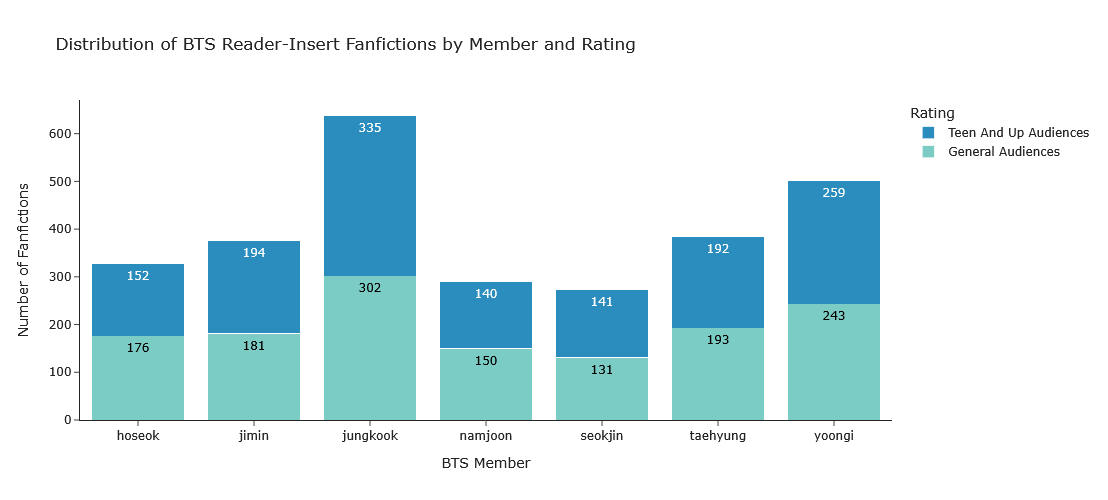

PNG already exists. Skipping.
HTML already exists. Skipping.


In [8]:
rating_counts = (
    fics[
        fics["rating"].isin([
            "General Audiences",
            "Teen And Up Audiences"
        ])
    ]
    .groupby(["member", "rating"])
    .size()
    .reset_index(name="count")
)

# Pivot so ratings become columns
rating_pivot = (
    rating_counts
    .pivot(
        index="member",
        columns="rating",
        values="count"
    )
    .fillna(0)
)

# Ensure consistent order
rating_pivot = rating_pivot[
    [
        "General Audiences",
        "Teen And Up Audiences"
    ]
]

# Stacked bar chart
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=rating_pivot.index,
        y=rating_pivot["General Audiences"],
        name="General Audiences",
        marker_color="#7bccc4",
        text=rating_pivot["General Audiences"].astype(int),
        textposition="inside",
        textfont=dict(color="black")
    )
)

fig.add_trace(
    go.Bar(
        x=rating_pivot.index,
        y=rating_pivot["Teen And Up Audiences"],
        name="Teen And Up Audiences",
        marker_color="#2b8cbe",
        text=rating_pivot["Teen And Up Audiences"].astype(int),
        textposition="inside",
        textfont=dict(color="white")
    )
)

fig.update_layout(
    barmode="stack",
    template="simple_white",
    width=800,
    height=500,

    title="Distribution of BTS Reader-Insert Fanfictions by Member and Rating",

    xaxis_title="BTS Member",
    yaxis_title="Number of Fanfictions",

    legend_title="Rating",

    font=dict(size=12)
)

fig.show()


png_file = (
    FICS_FIGURES_PATH /
    "11_genteen_member_fics.png"
)

html_file = (
    FICS_FIGURES_PATH /
    "11_genteen_member_fics.html"
)


if not png_file.exists():

    fig.write_image(
        png_file,
        width=800,
        height=500,
        scale=2
    )

    print(
        f"Saved PNG: {png_file}"
    )

else:

    print("PNG already exists. Skipping.")


if not html_file.exists():

    fig.write_html(
        html_file
    )

    print(
        f"Saved HTML: {html_file}"
    )

else:

    print("HTML already exists. Skipping.")

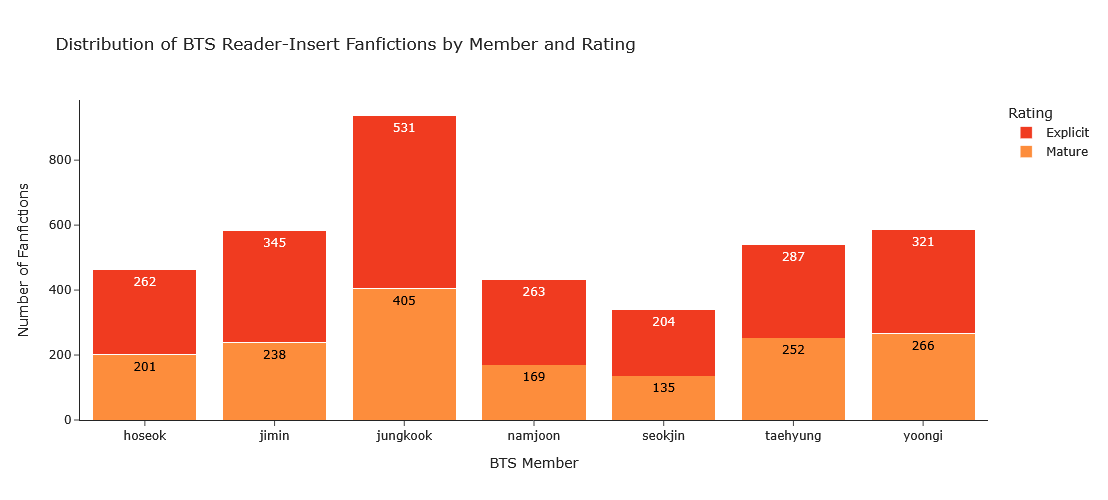

PNG already exists. Skipping.
HTML already exists. Skipping.


In [9]:
rating_counts = (
    fics[fics["rating"].isin(["Mature", "Explicit"])]
    .groupby(["member", "rating"])
    .size()
    .reset_index(name="count")
)

# Pivot so ratings become columns
rating_pivot = (
    rating_counts
    .pivot(index="member", columns="rating", values="count")
    .fillna(0)
)

# Ensure consistent order
rating_pivot = rating_pivot[
    ["Mature", "Explicit"]
]

# Stacked bar chart
rating_counts = (
    fics[fics["rating"].isin(["Mature", "Explicit"])]
    .groupby(["member", "rating"])
    .size()
    .reset_index(name="count")
)

rating_pivot = (
    rating_counts
    .pivot(index="member", columns="rating", values="count")
    .fillna(0)
)

rating_pivot = rating_pivot[
    ["Mature", "Explicit"]
]

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=rating_pivot.index,
        y=rating_pivot["Mature"],
        name="Mature",
        marker_color="#fd8d3c",
        text=rating_pivot["Mature"].astype(int),
        textposition="inside",
        textfont=dict(color="black")
    )
)

fig.add_trace(
    go.Bar(
        x=rating_pivot.index,
        y=rating_pivot["Explicit"],
        name="Explicit",
        marker_color="#f03b20",
        text=rating_pivot["Explicit"].astype(int),
        textposition="inside",
        textfont=dict(color="white")
    )
)

fig.update_layout(
    barmode="stack",
    template="simple_white",
    width=800,
    height=500,
    title="Distribution of BTS Reader-Insert Fanfictions by Member and Rating",
    xaxis_title="BTS Member",
    yaxis_title="Number of Fanfictions",
    legend_title="Rating",
    font=dict(size=12)
)

fig.show()


png_file = (
    FICS_FIGURES_PATH /
    "12_maturensfw_member_fics.png"
)

html_file = (
    FICS_FIGURES_PATH /
    "12_maturensfw_member_fics.html"
)


if not png_file.exists():

    fig.write_image(
        png_file,
        width=800,
        height=500,
        scale=2
    )

    print(
        f"Saved PNG: {png_file}"
    )

else:

    print("PNG already exists. Skipping.")


if not html_file.exists():

    fig.write_html(
        html_file
    )

    print(
        f"Saved HTML: {html_file}"
    )

else:

    print("HTML already exists. Skipping.")

## 3. Tag Co-Occurrence Network Community Detection Algorithm Experimentation

This section evaluates Louvain and Leiden community detection across a range of edge-weight and resolution parameters. The pipeline includes functions for:

- parsing and filtering fanfiction tags;
- setting parameters across edge weight, resolution, and AO3 ratings
- constructing tag co-occurrence graphs and networks;
- running Louvain and Leiden community detection;
- identifying the most frequent tags within each detected community as interpretive summaries of each cluster;
- saving experimental results for evaluation and comparison; and
- executing the complete pipeline across all parameter configurations, while avoiding recomputation when results already exist in the output directory.

### 3.1 Parsing Tags into Lists

This section defines a function to parse the `canonical_tags` column into Python lists for network construction and community detection. Missing or invalid values are converted to empty lists, while existing lists are preserved. The tag networks do not consider empty tags in the corpus. 

In [10]:
#parse tags

def parse_tags(tags):

    if pd.isna(tags):
        return []

    if isinstance(tags, list):
        return tags

    if isinstance(tags, str):

        try:
            return ast.literal_eval(tags)

        except Exception:
            return []

    return []


fics["network_tags"] = (
    fics["canonical_tags"]
    .apply(parse_tags)
)

In [11]:
fics["network_tags"].head()

0    [Amnesia, Angst, Arranged Marriage, Drama, Imp...
1    [Cat/Human Hybrids, Fluff, Hybrids, One Shot C...
2    [Complete, Fluff, Fluff and Angst, Romance, Un...
3    [Hurt/Comfort, Hybrids, Recovery, Slow Burn, S...
4    [Aliens, Alternate Universe - Aliens, Alternat...
Name: network_tags, dtype: object

In [12]:
empty_network_tags = (
    fics["network_tags"]
    .apply(lambda x: isinstance(x, list) and x == [])
    .sum()
)

print(f"Records with no network tags: {empty_network_tags:,}")

Records with no network tags: 722


A small proportion of works (10%) contained no canonical tags and therefore could not contribute to canonical tag co-occurrence relationships. These works were retained in the overall corpus but excluded from network construction (df in this notebook), as their absence of canonical nodes prevents meaningful placement within the tag-based network.

In [13]:
fics = fics[
    fics["network_tags"].apply(lambda x: x != [])
].copy()

In [14]:
fics.shape

(5946, 18)

### 3.2 Experiment Parameters of Edge Weights and Resolutions 

This section defines the parameter values used to evaluate the Louvain and Leiden community detection algorithms. The experiments vary the minimum edge-weight threshold and resolution parameter across four AO3 rating categories: General Audiences, Teen And Up Audiences, Mature, and Explicit.

In [15]:
#experiment parameters 


EDGE_WEIGHTS = [1, 2, 3, 4, 5, 6]

RESOLUTIONS = [
    1.0,
    1.5,
    2.0,
    2.5,
    3.0,
    3.5
]

RATINGS = [
    "General Audiences",
    "Teen And Up Audiences",
    "Mature",
    "Explicit"
]

### 3.3 Function for Building the Tag Co-Occurrence Graph

This function constructs a weighted tag co-occurrence graph by identifying pairs of canonical tags that appear together within the same fanfiction work. It also calculates the frequency of each tag and records the unique GOLEM database ID of the fanfiction works in which each tag appears. The resulting edge list, tag frequencies, and tag-to-fanwork mappings are used in subsequent network construction and community detection.

In [16]:
#build tag co-occurence graph 

def build_graph(df):

    tag_frequency = Counter()

    edge_counter = Counter()

    tag_fics = defaultdict(set)


    for _, row in df.iterrows():

        tags = row["network_tags"]

        tags = list(set(tags))


        for tag in tags:

            tag_frequency[tag] += 1

            tag_fics[tag].add(row["s"])



        for a, b in combinations(sorted(tags), 2):

            edge_counter[(a, b)] += 1



    edges = pd.DataFrame(
        [
            {
                "source": a,
                "target": b,
                "weight": weight
            }

            for (a, b), weight in edge_counter.items()
        ]
    )


    return edges, tag_frequency, tag_fics

In [17]:
edges, freq, tag_fics = build_graph(fics)

print(edges.head())
print("Number of edges:", len(edges))

print(list(tag_fics.items())[:5])

    source                      target  weight
0  Amnesia                       Angst       1
1  Amnesia           Arranged Marriage       1
2  Amnesia                       Drama       1
3  Amnesia  Implied/Referenced Suicide       1
4  Amnesia            Past Child Abuse       1
Number of edges: 96648
[('Implied/Referenced Suicide', {'https://golemlab.eu/graph/12397809', 'https://golemlab.eu/graph/22426168', 'https://golemlab.eu/graph/18497734', 'https://golemlab.eu/graph/10435611', 'https://golemlab.eu/graph/13801209', 'https://golemlab.eu/graph/30270858', 'https://golemlab.eu/graph/27125071', 'https://golemlab.eu/graph/10772472', 'https://golemlab.eu/graph/27311425', 'https://golemlab.eu/graph/40940598', 'https://golemlab.eu/graph/35402125', 'https://golemlab.eu/graph/12602888', 'https://golemlab.eu/graph/40388676', 'https://golemlab.eu/graph/38994522', 'https://golemlab.eu/graph/11070909', 'https://golemlab.eu/graph/28624380', 'https://golemlab.eu/graph/26863420', 'https://golemla

### 3.4 Function for Constructing Tag Co-Occurence Network 

This function constructs a weighted ``NetworkX graph`` from the tag co-occurrence edge list, which can later be used to visualize in *Gephi*. Edges are filtered using the specified minimum co-occurrence weight threshold, retaining only sufficiently frequent tag connections for community detection.

In [18]:
#construct network 


def build_network(edges, min_weight):

    filtered_edges = edges[
        edges.weight >= min_weight
    ]


    G = nx.Graph()


    for _, row in filtered_edges.iterrows():

        G.add_edge(
            row.source,
            row.target,
            weight=row.weight
        )


    return G

### 3.5 Functions for Louvain and Leiden Community Detection

These functions apply Louvain and Leiden community detection to the weighted tag co-occurrence network. Both algorithms use the specified resolution parameter and edge weights to identify communities, with a fixed random seed for reproducibility. Each function returns the community assignments and modularity score for evaluating the resulting network structure in the later steps.

In [19]:
#community detection algorithms- louvain and leiden


def run_louvain(G, resolution):

    partition = community_louvain.best_partition(
        G,
        weight="weight",
        resolution=resolution,
        random_state=42
    )


    modularity = community_louvain.modularity(
        partition,
        G,
        weight="weight"
    )


    return partition, modularity


def run_leiden(G, resolution):

    nodes = list(G.nodes())


    node_to_id = {
        node:i
        for i,node in enumerate(nodes)
    }


    edges = [
        (
            node_to_id[u],
            node_to_id[v]
        )
        for u,v in G.edges()
    ]


    weights = [
        G[u][v]["weight"]
        for u,v in G.edges()
    ]


    graph = ig.Graph(
        n=len(nodes),
        edges=edges,
        directed=False
    )


    graph.vs["name"] = nodes


    partition = leidenalg.find_partition(
        graph,
        leidenalg.RBConfigurationVertexPartition,
        weights=weights,
        resolution_parameter=resolution,
        seed=42
    )


    communities = {}


    for cid, cluster in enumerate(partition):

        for vertex in cluster:

            communities[
                graph.vs[vertex]["name"]
            ] = cid


    return communities, partition.modularity






### 3.6 Function for Structuring Community Detection Results

This function converts the community assignments produced by the Louvain or Leiden algorithms into a DataFrame. Each row represents a tag and records the community to which it has been assigned. The function then adds two additional metadata fields: the frequency of the tag across the relevant fanfiction subset and the list of fanfiction IDs in which the tag occurs.

This structure allows the detected communities to be examined alongside the prevalence and corpus distribution of their constituent tags. These metadata are subsequently used to identify and interpret the most prominent tags within each community.

In [20]:
#convert communities to DataFrame

def cluster_dataframe(
    partition,
    tag_frequency,
    tag_fics
):
    df = pd.DataFrame(
        {
            "tag": list(partition.keys()),
            "community": list(partition.values())
        }
    )


    df["frequency"] = (
        df["tag"]
        .map(tag_frequency)
    )

    df["fic_ids"] = (
    df["tag"]
    .map(tag_fics)
    .apply(list)
)


    return df


### 3.7 Function for Summarizing Community Structure in Cluster

This function calculates descriptive statistics for the communities identified by each community detection algorithm. It first determines the size of each community by counting the number of tags assigned to it.

The function then summarizes the overall structure of the detected communities using the following measures:

- **Number of communities:** total number of communities detected.
- **Largest community:** number of tags in the largest community.
- **Largest community proportion:** proportion of all tags belonging to the largest community.
- **Smallest community:** number of tags in the smallest community.
- **Average community size:** mean number of tags per community.
- **Median community size:** median number of tags per community, providing a more robust measure when community sizes are unevenly distributed.
- **Singleton communities:** number of communities containing only one tag.

These statistics provide a compact quantitative description of community structure so the Louvain and Leiden results can be compared across different edge-weight and resolution parameter settings.

In [21]:
#cluster stats


def summarize_clusters(df):

    sizes = (
        df
        .groupby("community")
        .size()
        .sort_values(
            ascending=False
        )
    )


    total_nodes = len(df)

    singleton_count = (
        sizes == 1
    ).sum()


    return {

        # number of detected communities
        "communities": len(sizes),


        # largest community size
        "largest": sizes.max(),


        # largest community proportion
        "largest_pct":
            sizes.max() / total_nodes,


        # smallest community
        "smallest": sizes.min(),


        # average community size
        "average": sizes.mean(),


        # median community size
        "median": sizes.median(),


        # number of singleton clusters
        "singleton_count":
            singleton_count

    }


### 3.8 Function for Executing the Experiment Pipeline

This function executes the complete community detection experiment pipeline for a single combination of rating category, algorithm, edge-weight threshold, and resolution parameter.

The pipeline:

1. Builds the weighted tag co-occurrence graph from the selected fanfiction subset.
2. Filters the graph according to the specified minimum edge weight.
3. Applies either the Louvain or Leiden community detection algorithm at the given resolution.
4. Stores the resulting partition for later stability analysis using the Adjusted Rand Index (ARI).
5. Converts the community assignments into a DataFrame containing tag frequencies and associated fanfiction IDs.
6. Aggregates fanfiction IDs within each community to identify the works represented by each detected community.
7. Calculates structural statistics describing the detected communities.
8. Records experiment metadata, including the rating category, algorithm, edge-weight threshold, resolution, network size, number of edges, and modularity score.
9. Returns the summary statistics and detailed community-level DataFrame for subsequent comparison and interpretation.

Empty networks are skipped to prevent invalid community detection runs.

In [22]:
# function for the experiment

def experiment(
    subset,
    rating,
    algorithm,
    min_weight,
    resolution,
    model_partitions,
    model_id
):

    # 1. Build tag co-occurrence network

    edges, freq, tag_fics = build_graph(subset)


    G = build_network(
        edges,
        min_weight
    )


    # Skip empty networks
    if G.number_of_nodes() == 0:
        return None



    # 2. Detect communities

    if algorithm == "Leiden":

        partition, modularity = run_leiden(
            G,
            resolution
        )

    elif algorithm == "Louvain":

        partition, modularity = run_louvain(
            G,
            resolution
        )



    # 3. Store partition for ARI stability analysis

    model_partitions.append(
        {
            "rating": rating,
            "algorithm": algorithm,
            "edge_weight": min_weight,
            "resolution": resolution,
            "partition": partition
        }
    )



    # 4. Convert partition into dataframe for cluster analysis

    clusters = cluster_dataframe(
        partition,
        freq,
        tag_fics
    )


    community_fics = (
    clusters
    .groupby("community")["fic_ids"]
    .apply(
        lambda x: sorted(
            set(
                fic
                for sublist in x
                for fic in sublist
            )
        )
    )
    .reset_index()
    .rename(
        columns={
            "fic_ids": "community_fic_ids"
        }
    )
)


    # 5. Calculate structural cluster metrics

    summary = summarize_clusters(
        clusters
    )



    # 6. Add experiment metadata

    summary.update(
        {
            "model_id":model_id,
            "rating": rating,
            "algorithm": algorithm,
            "edge_weight": min_weight,
            "resolution": resolution,

            # network properties
            "nodes": G.number_of_nodes(),
            "edges": G.number_of_edges(),

            # partition quality
            "modularity": modularity
        }
    )


    return summary, clusters

### 3.9 Execute Experiment and Save Community Detection Results

This section runs the complete experimental parameter sweep across all specified rating categories, edge-weight thresholds, resolution values, and community detection algorithms.

For each combination, the pipeline executes the community detection experiment and stores both the overall evaluation metrics and the tag-level community assignments. The resulting outputs are combined into two DataFrames:

- `results_df`: summary statistics and network-level evaluation metrics for each experimental configuration.
- `all_clusters`: tag-level community assignments, frequencies, and associated fanfiction IDs for each configuration.

To avoid unnecessarily repeating computationally expensive experiments, the code first checks whether previously generated result files exist. If they do, the saved results and model partitions are loaded instead of rerunning the parameter sweep.

When the experiment is run, the resulting data are saved as CSV files, while the community partitions are saved as a pickle file for subsequent ARI-based stability analysis. The summary results are also sorted by algorithm, rating category, and modularity to facilitate inspection and comparison of experimental configurations.

In [23]:
results_file = RESULTS_DIR / "results_df.csv"
clusters_file = RESULTS_DIR / "all_clusters.csv"

if results_file.exists() and clusters_file.exists():

    print("Results already exist. Loading saved files...")

    results_df = pd.read_csv(results_file)
    all_clusters = pd.read_csv(clusters_file)

    import pickle

    partitions_file = RESULTS_DIR / "model_partitions.pkl"
    
    if partitions_file.exists():
    
        print("Loading model partitions.")
    
        with open(
            partitions_file,
            "rb"
        ) as f:
            model_partitions = pickle.load(f)
    
    else:
    
        print("model_partitions.pkl not found.")

    results_df_sorted = (
        results_df
        .sort_values(
            [
                "algorithm",
                "rating",
                "modularity"
            ],
            ascending=[
                True,
                True,
                False
            ]
        )
    )

else:

    print("Running parameter sweep...")

    results = []
    cluster_tables = []
    model_partitions = []
    model_id=1

    for rating in RATINGS:

        print("\n===================")
        print(rating)
        print("===================")

        if rating == "ALL":
            subset = fics.copy()
        else:
            subset = (
                fics[
                    fics["rating"] == rating
                ].copy()
            )

        for weight in EDGE_WEIGHTS:

            for resolution in RESOLUTIONS:

                for algorithm in [
                    "Louvain",
                    "Leiden"
                ]:

                    print(
                        algorithm,
                        weight,
                        resolution
                    )

                    output = experiment(
                        subset,
                        rating,
                        algorithm,
                        weight,
                        resolution,
                        model_partitions,
                        model_id
                    )

                    if output is None:
                        continue

                    summary, clusters = output

                    results.append(summary)

                    clusters["rating"] = rating
                    clusters["algorithm"] = algorithm
                    clusters["edge_weight"] = weight
                    clusters["resolution"] = resolution

                    cluster_tables.append(clusters)

                    model_id += 1

    # Create dataframes
    results_df = pd.DataFrame(results)
    all_clusters = pd.concat(
        cluster_tables,
        ignore_index=True
    )

    # Add dataset column
    results_df["dataset"] = "Model Evaluation Results"

    # Sorted version (for display only)
    results_df_sorted = (
        results_df
        .sort_values(
            [
                "algorithm",
                "rating",
                "modularity"
            ],
            ascending=[
                True,
                True,
                False
            ]
        )
    )

    # Save
    RESULTS_DIR.mkdir(exist_ok=True)
    
    results_df.to_csv(
        results_file,
        index=False
    )
    
    all_clusters.to_csv(
        clusters_file,
        index=False
    )
    
    
    # Save model partitions for ARI calculation later
    import pickle
    
    with open(
        RESULTS_DIR / "model_partitions.pkl",
        "wb"
    ) as f:
        pickle.dump(
            model_partitions,
            f
        )
    
    
    print("Results and model partitions saved.")

Results already exist. Loading saved files...
Loading model partitions.


## 4. Evaluating Louvain–Leiden Algorithmic Agreement with ARI

This section compares the community structures produced by **Louvain** and **Leiden** using the **Adjusted Rand Index (ARI)**.

ARI measures how similarly two algorithms (Louvain and Leiden) assign tags to communities, with higher values indicating greater agreement.

The comparison is restricted to models with the same:

- rating category;
- edge-weight threshold; and
- resolution parameter.

This ensures that Louvain and Leiden are compared under identical experimental conditions.

For each matching pair, the pipeline:

1. matches each partition to its `model_id`;
2. identifies tags shared by both partitions;
3. extracts their community assignments from Louvain and Leiden;
4. calculates the ARI between the two partitions; and
5. stores the comparison and experimental parameters in `ari_df`.

The resulting ARI scores are saved as `ari_df.csv` for subsequent evaluation of algorithmic consistency and model selection.

If the ARI results already exist, the saved file is loaded instead of recalculating them.

In [24]:
def calculate_algorithm_ari(model_partitions):

    ari_results = []

    # compare every pair of partitions
    for i in range(len(model_partitions)):

        for j in range(i + 1, len(model_partitions)):

            p1 = model_partitions[i]
            p2 = model_partitions[j]


            # Only compare different algorithms
            if p1["algorithm"] == p2["algorithm"]:
                continue


            # Same experimental condition
            if p1["rating"] != p2["rating"]:
                continue

            if p1["edge_weight"] != p2["edge_weight"]:
                continue

            if p1["resolution"] != p2["resolution"]:
                continue


            # shared nodes
            nodes = (
                set(p1["partition"].keys())
                &
                set(p2["partition"].keys())
            )


            if len(nodes) == 0:
                continue


            labels1 = [
                p1["partition"][node]
                for node in nodes
            ]

            labels2 = [
                p2["partition"][node]
                for node in nodes
            ]


            ari = adjusted_rand_score(
                labels1,
                labels2
            )


            ari_results.append(
                {   "model_id_1": p1["model_id"],
                    "model_id_2": p2["model_id"],
                    "rating": p1["rating"],
                    "edge_weight": p1["edge_weight"],
                    "resolution": p1["resolution"],
                    "algorithm_1": p1["algorithm"],
                    "algorithm_2": p2["algorithm"],
                    "ARI": ari
                }
            )


    return pd.DataFrame(ari_results)

In [25]:
model_lookup = results_df[
    [
        "model_id",
        "rating",
        "algorithm",
        "edge_weight",
        "resolution"
    ]
]


for partition in model_partitions:

    match = model_lookup[
        (model_lookup["rating"] == partition["rating"]) &
        (model_lookup["algorithm"] == partition["algorithm"]) &
        (model_lookup["edge_weight"] == partition["edge_weight"]) &
        (model_lookup["resolution"] == partition["resolution"])
    ]

    if len(match) == 1:
        partition["model_id"] = match.iloc[0]["model_id"]
    else:
        print(
            "Model ID not found:",
            partition["rating"],
            partition["algorithm"],
            partition["edge_weight"],
            partition["resolution"]
        )



ari_file = RESULTS_DIR / "ari_df.csv"

if ari_file.exists():
    print("ari_df.csv already exists. Loading...")
    ari_df = pd.read_csv(ari_file)

else:
    print("Calculating ARI...")
    
    ari_df = calculate_algorithm_ari(
        model_partitions
    )

    ari_df["dataset"] = "ARI Stability Results"


    ari_df.to_csv(
        ari_file,
        index=False
    )

    print("Saved ari_df.csv")

display(ari_df.head())

ari_df.csv already exists. Loading...


,model_id_1,model_id_2,rating,edge_weight,resolution,algorithm_1,algorithm_2,ARI,dataset
0,1,2,General Audiences,1,1.0,Louvain,Leiden,0.355378,ARI Stability Results
1,3,4,General Audiences,1,1.5,Louvain,Leiden,0.562232,ARI Stability Results
2,5,6,General Audiences,1,2.0,Louvain,Leiden,0.640483,ARI Stability Results
3,7,8,General Audiences,1,2.5,Louvain,Leiden,0.665546,ARI Stability Results
4,9,10,General Audiences,1,3.0,Louvain,Leiden,0.595907,ARI Stability Results


In [26]:
# remove old model_id if already present
if "model_id" in all_clusters.columns:

    all_clusters = all_clusters.drop(
        columns=["model_id"]
    )


all_clusters = all_clusters.merge(
    results_df[
        [
            "model_id",
            "rating",
            "algorithm",
            "edge_weight",
            "resolution"
        ]
    ],
    on=[
        "rating",
        "algorithm",
        "edge_weight",
        "resolution"
    ],
    how="left"
)


# check missing IDs
print(
    "Missing model IDs:",
    all_clusters["model_id"].isna().sum()
)


# save updated clusters
all_clusters.to_csv(
    RESULTS_DIR / "all_clusters.csv",
    index=False
)


print(
    "Saved updated all_clusters.csv"
)

Missing model IDs: 0
Saved updated all_clusters.csv


In [27]:
ari_summary_file = RESULTS_DIR / "ari_summary_config.csv"

if ari_summary_file.exists():
    print("ari_summary_config.csv already exists. Loading...")
    
    ari_summary_config = pd.read_csv(
        ari_summary_file
    )

else:
    print("Creating ari_summary_config...")

    ari_summary_config = (
        ari_df
        .groupby(
            [
                "rating",
                "edge_weight",
                "resolution"
            ]
        )["ARI"]
        .mean()
        .reset_index()
    )

    ari_summary_config.to_csv(
        ari_summary_file,
        index=False
    )

    print("Saved ari_summary_config.csv")

display(
    ari_summary_config.head()
)

ari_summary_config.csv already exists. Loading...


,rating,edge_weight,resolution,ARI
0,Explicit,1,1.0,0.415962
1,Explicit,1,1.5,0.413894
2,Explicit,1,2.0,0.484504
3,Explicit,1,2.5,0.571279
4,Explicit,1,3.0,0.544533


## 5. Identifying Dominant and Distinctive Tags Within Communities

This section summarizes the tags associated with each detected community using **raw frequency** and **Pointwise Mutual Information (PMI)** to support qualitative interpretation of the network clusters.

For each experimental network model, the pipeline:

1. Calculates the total frequency of all tags in the model.
2. Calculates the overall frequency of each tag.
3. Calculates the total tag frequency within each community.
4. Computes **PMI** for each tag within its assigned community:

   \[
   PMI(tag, community) =
   \log_2
   \frac{P(tag, community)}
   {P(tag)\,P(community)}
   \]

   where:
   - \(P(tag, community)\) is the frequency of the tag within the community relative to the model's total tag frequency;
   - \(P(tag)\) is the overall frequency of the tag within the model; and
   - \(P(community)\) is the community's total tag frequency relative to the model.

5. For each community, identifies:
   - the **top 8 tags by frequency**, representing the most dominant tags;
   - the **top 5 tags by PMI**, representing the most distinctive or disproportionately associated tags.

The resulting community summaries retain the **community size** and the **IDs of fanfiction works associated with each community**. These are then merged with the corresponding model-level evaluation metrics to support comparison of community structure and thematic content.

The completed results are saved as `cluster_results.csv`. If this file already exists, the saved results are loaded rather than recalculating the community summaries.

In [28]:

all_clusters["fic_ids"] = (
    all_clusters["fic_ids"]
    .apply(ast.literal_eval)
)

In [29]:

all_clusters["fic_ids"] = (
    all_clusters["fic_ids"]
    .apply(
        lambda x: ast.literal_eval(x)
        if isinstance(x, str)
        else x
    )
)
cluster_results_file = RESULTS_DIR / "cluster_results.csv"

if cluster_results_file.exists():

    print("Loading existing cluster results...")

    cluster_results = pd.read_csv(
        cluster_results_file
    )

else:

    print("Generating cluster summaries...")

    TOP_N_FREQUENCY = 8
    TOP_N_PMI = 5

    cluster_summaries = []


    # Process ONE MODEL AT A TIME

    for (
        rating,
        algorithm,
        edge_weight,
        resolution
    ), model_df in all_clusters.groupby(
        [
            "rating",
            "algorithm",
            "edge_weight",
            "resolution"
        ]
    ):

        community_fics = (
            model_df
            .groupby("community")["fic_ids"]
            .apply(
                lambda x: sorted(
                    set(
                        fic
                        for sublist in x
                        for fic in sublist
                    )
                )
            )
            .to_dict()
        )


        total_frequency = model_df["frequency"].sum()

        tag_totals = (
            model_df
            .groupby("tag")["frequency"]
            .sum()
        )


        for community, group in model_df.groupby("community"):

            community_total = group["frequency"].sum()

            scores = []

            for _, row in group.iterrows():

                tag = row["tag"]
                freq = row["frequency"]

                p_tag_comm = freq / total_frequency
                p_tag = tag_totals[tag] / total_frequency
                p_comm = community_total / total_frequency

                pmi = np.log2(
                    p_tag_comm /
                    (p_tag * p_comm)
                )

                scores.append(
                    {
                        "tag": tag,
                        "frequency": freq,
                        "PMI": pmi
                    }
                )


            scores = pd.DataFrame(scores)


            top_frequency = (
                scores
                .sort_values(
                    "frequency",
                    ascending=False
                )
                .head(TOP_N_FREQUENCY)
            )


            top_pmi = (
                scores
                .sort_values(
                    "PMI",
                    ascending=False
                )
                .head(
                    min(
                        TOP_N_PMI,
                        len(scores)
                    )
                )
            )


            cluster_summaries.append(
                {
                    "model_id": model_df["model_id"].iloc[0],
                    "rating": rating,
                    "algorithm": algorithm,
                    "edge_weight": edge_weight,
                    "resolution": resolution,
                    "community": community,
                    "cluster_size": len(group),
                    "community_fic_ids": json.dumps(
    community_fics[community]
),
                    "top_tags": "; ".join(
                        f"{r.tag} ({r.frequency})"
                        for _, r in top_frequency.iterrows()
                    ),

                    "top_pmi_tags": "; ".join(
                        top_pmi["tag"]
                    )
                }
            )


    cluster_summary_df = pd.DataFrame(
        cluster_summaries
    )


    cluster_results = (
        cluster_summary_df
        .merge(
            results_df.drop(
                columns=[
                    "rating",
                    "algorithm",
                    "edge_weight",
                    "resolution"
                ],
                errors="ignore"
            ),
            on="model_id",
            how="left"
        )
        .sort_values(
            [
                "model_id",
                "community"
            ]
        )
        .reset_index(drop=True)
    )
    cluster_results["dataset"] = "Cluster Interpretation Results"



    # Save for future runs
    cluster_results.to_csv(
        cluster_results_file,
        index=False
    )

    cluster_summary_file = RESULTS_DIR / "cluster_summary_df.csv"


display(cluster_results.head())

Loading existing cluster results...


,model_id,rating,algorithm,edge_weight,resolution,community,cluster_size,community_fic_ids,top_tags,top_pmi_tags,...,largest,largest_pct,smallest,average,median,singleton_count,nodes,edges,modularity,dataset
0,1,General Audiences,Louvain,1,1.0,0,2,"[""https://golemlab.eu/graph/40565706""]",Age Regression/De-Aging (1); Non-Sexual Age Pl...,Age Regression/De-Aging; Non-Sexual Age Play,...,172,0.201405,2,40.666667,18.0,0,854,6368,0.319189,Cluster Interpretation Results
1,1,General Audiences,Louvain,1,1.0,1,59,"[""https://golemlab.eu/graph/10322501"", ""https:...",One Shot (84); Short One Shot (31); Short & Sw...,I Tried; One Shot; Short One Shot; How Do I Ta...,...,172,0.201405,2,40.666667,18.0,0,854,6368,0.319189,Cluster Interpretation Results
2,1,General Audiences,Louvain,1,1.0,2,172,"[""https://golemlab.eu/graph/10053617"", ""https:...",Fluff (616); Drabble (85); Domestic Fluff (76)...,Reader-Insert; Fluff; Domestic Fluff; Tooth-Ro...,...,172,0.201405,2,40.666667,18.0,0,854,6368,0.319189,Cluster Interpretation Results
3,1,General Audiences,Louvain,1,1.0,3,87,"[""https://golemlab.eu/graph/10291481"", ""https:...",Friends to Lovers (57); Alternate Universe - C...,Alternate Universe - College/University; Best ...,...,172,0.201405,2,40.666667,18.0,0,854,6368,0.319189,Cluster Interpretation Results
4,1,General Audiences,Louvain,1,1.0,4,63,"[""https://golemlab.eu/graph/10322906"", ""https:...",Romantic Fluff (28); Love Confessions (15); Un...,Comedy; Romantic Comedy; Romantic Fluff; Confe...,...,172,0.201405,2,40.666667,18.0,0,854,6368,0.319189,Cluster Interpretation Results


## 6. Consolidating Model Evaluation and Community Interpretations

This section combines the quantitative evaluation results, algorithmic stability measures, and qualitative community summaries into a single table for model comparison.

The pipeline:

1. groups community-level results by experimental configuration and combines the detected communities into a single textual summary;
2. includes the **top frequency tags** and **top PMI tags** for each community;
3. merges these community interpretations with the overall network metrics from `results_df`;
4. adds the corresponding **ARI stability results** for comparing Louvain and Leiden under the same experimental conditions; and
5. assigns a sequential `model_id` to each experimental configuration and moves it to the first column.

The resulting `evaluation_df` provides a consolidated view of each model's **network structure, community quality, algorithmic consistency, and interpretive tag composition**, facilitating comparison and selection of the final community detection configuration in section 7.

In [30]:
model_interpretation = (
    cluster_results
    .sort_values("community")
    .groupby(
        [
            "rating",
            "algorithm",
            "edge_weight",
            "resolution"
        ]
    )
    .apply(
        lambda x: "\n\n".join(
            [
                f"""Community {row.community} ({row.cluster_size} tags):

Top frequency tags:
{row.top_tags}

Top PMI tags (distinctive tags):
{row.top_pmi_tags}"""
                for _, row in x.iterrows()
            ]
        )
    )
    .reset_index(
        name="community_summaries"
    )
)

In [31]:
evaluation_df = (
    results_df
    .merge(
        ari_summary_config,
        on=["rating", "edge_weight", "resolution"],
        how="left"
    )
    .merge(
        model_interpretation,
        on=["rating", "algorithm", "edge_weight", "resolution"],
        how="left"
    )
    # Highlight: Create an iterative ID starting at 1
    .assign(model_id=lambda df: range(1, len(df) + 1))
)

In [32]:
# Move 'id' to index 0 (the very first column)
id_col = evaluation_df.pop("model_id")
evaluation_df.insert(0, "model_id", id_col)

In [33]:
evaluation_df.columns

Index(['model_id', 'communities', 'largest', 'largest_pct', 'smallest',
       'average', 'median', 'singleton_count', 'rating', 'algorithm',
       'edge_weight', 'resolution', 'nodes', 'edges', 'modularity', 'dataset',
       'ARI', 'community_summaries'],
      dtype='str')

In [34]:
evaluation_df.to_csv(
    RESULTS_DIR / "evaluation_df.csv",
    index=False
)

## 7. Quantitative Evaluation of Community Detection Models

To identify the strongest-performing community detection models, each experimental configuration is evaluated using six structural and stability-based criteria. The criteria capture **algorithmic agreement, network structure, community-size balance, interpretability of community count, and fragmentation**.

Each criterion is converted to a score from **1 to 5** and combined using the following weights:

| Criterion | Weight | Description |
|---|---:|---|
| **Algorithmic Agreement (ARI)** | 25% | Measures agreement between Louvain and Leiden partitions under identical experimental conditions. Higher ARI indicates greater consistency between algorithms. |
| **Modularity** | 20% | Measures the strength of the detected community structure. Higher modularity indicates more clearly separated communities. |
| **Size Balance** | 15% | Evaluates whether the partition avoids excessive dominance by a single large community while retaining reasonably sized smaller communities. |
| **Size Distribution** | 10% | Measures how evenly community sizes are distributed using the ratio of median to average community size. |
| **Number of Communities** | 20% | Rewards models producing a manageable and interpretable number of communities. Models with approximately **15–25 communities** receive the highest score. |
| **Fragmentation** | 10% | Penalizes excessive fragmentation by measuring the proportion of singleton communities. A lower proportion of singleton communities receives a higher score. |


The **ARI** and **modularity** scores are assigned using quintiles, with higher values receiving higher scores. The size-balance metric combines the proportion of the largest community with the relative size of the smallest community; lower values receive higher scores. Size distribution is assessed using the **median-to-average community-size ratio**, with higher values indicating a more balanced distribution.

The number-of-communities criterion assigns the highest score to models with **15–25 communities**, while progressively lower scores are assigned to configurations with fewer or substantially more communities. Fragmentation is measured as the proportion of singleton communities:

\[
\text{Fragmentation} =
\frac{\text{Number of Singleton Communities}}
{\text{Total Number of Communities}}
\]

Lower fragmentation therefore receives a higher score.

The weighted quantitative score is calculated as:

\[
\begin{aligned}
\text{Quantitative Score} ={}&
(ARI \times 0.25) +
(Modularity \times 0.20) \\
&+ (Size\ Balance \times 0.15) +
(Size\ Distribution \times 0.10) \\
&+ (Community\ Number \times 0.20) +
(Fragmentation \times 0.10)
\end{aligned}
\]

The resulting score is normalized to a maximum of **100 points**:

\[
\text{Score}_{100} =
\frac{\text{Quantitative Score}}{5}
\times 100
\]

Models are then ranked according to this score. The quantitative ranking is used to identify the strongest candidate configurations Since the quantitative criteria cannot fully determine whether a community corresponds to a meaningful fanfiction convention, the highest-ranked models are subsequently examined through their dominant and distinctive tags as a **qualitative interpretation**. The selected models are also subjected to a **Leiden seed stability analysis**, where community detection is repeated across multiple random seeds and compared using ARI to assess the robustness of the resulting cluster partitions.

### 7.1 Evaluation Criterion Function

In [35]:
def evaluate_models(df):

    df = df.copy()

    # 1. ARI score (25%)
    df["ARI_score"] = pd.qcut(
        df["ARI"],
        5,
        labels=[1,2,3,4,5]
    ).astype(int)


    # 2. Modularity score (20%)
    df["modularity_score"] = pd.qcut(
        df["modularity"],
        5,
        labels=[1,2,3,4,5]
    ).astype(int)


    # 3. Size Balance score (10%)
    df["size_balance_metric"] = (
        df["largest_pct"] +
        (df["smallest"] / df["average"])
    )

    df["size_balance_score"] = pd.qcut(
        -df["size_balance_metric"],
        5,
        labels=[1,2,3,4,5]
    ).astype(int)


    # 4. Size Distribution score (10%)
    df["median_average_ratio"] = (
        df["median"] / df["average"]
    )

    df["size_distribution_score"] = pd.qcut(
        df["median_average_ratio"],
        5,
        labels=[1,2,3,4,5]
    ).astype(int)


    # 5. Number of Communities score (5%)
    df["community_score"] = df["communities"].apply(
            lambda x:
                5 if 15 <= x <= 25 else
                4 if 31 <= x <= 50 else
                3 if 10 <= x <= 15 else
                2 if 51 <= x < 80 else
                1
        )


    # 6. Fragmentation score (5%)
    df["fragmentation_metric"] = (
        df["singleton_count"] / df["communities"]
    )
    def fragmentation_score(x):
        if x == 0:
            return 5
        elif x <= 0.05:
            return 4
        elif x <= 0.15:
            return 3
        elif x <= 0.30:
            return 2
        else:
            return 1
    
    
    df["fragmentation_score"] = df["fragmentation_metric"].apply(
        fragmentation_score
    )


    # Weighted quantitative score
    df["quantitative_score"] = (
        df["ARI_score"] * 0.25 +
        df["modularity_score"] * 0.20 +
        df["size_balance_score"] * 0.15 +
        df["size_distribution_score"] * 0.10 +
        df["community_score"] * 0.20 +
        df["fragmentation_score"] * 0.10
    )


    # Convert to score out of 100
    df["score_out_of_100"] = (
        df["quantitative_score"] / 5 * 100
    )


    # Rank models
    df = df.sort_values(
        "score_out_of_100",
        ascending=False
    ).reset_index(drop=True)


    # Create ranking table
    ranking_df = (
        df[
            [
                "model_id",
                "score_out_of_100",
                "rating",
                "algorithm",
                "edge_weight",
                "resolution",
                "communities",
                "largest",
                "largest_pct",
                "ARI",
                "modularity",
                "smallest",
                "singleton_count",
                "average",
                "median",
                "nodes",
                "edges"
            ]
        ]
        
    )



    return ranking_df

### 7.2 Leiden Seed Stability Analysis

The seed stability analysis is conducted using **Leiden** because the quantitative model evaluation (as we will see in section 8) identifies Leiden configurations as the strongest-performing models across the experimental parameter space. Since the highest-ranked candidate models are predominantly produced by Leiden, the stability test focuses on whether these selected community structures remain consistent across different random initializations.

For each selected Leiden model:

1. Reconstruct the tag co-occurrence network using the model's **rating category** and **edge-weight threshold**.
2. Run Leiden community detection using the model's **resolution parameter** across multiple random seeds.
3. Store the resulting community partitions for each seed.
4. Compare every pair of seed-specific partitions using the **Adjusted Rand Index (ARI)**.
5. Calculate the mean ARI across all seed comparisons for each model.

The analysis uses the seeds **1, 10, 42, and 100**. A higher mean seed ARI indicates that the detected communities remain more consistent across different random initializations, providing stronger evidence that the identified community structure is robust rather than dependent on a particular random seed.

The resulting `seed_summary` ranks the selected models by their **mean seed ARI**. This provides an additional stability criterion for selecting the final community detection models alongside the quantitative evaluation and subsequent qualitative interpretation.

In [36]:
def run_leiden_seed(G, resolution, seed):

    nodes = list(G.nodes())

    node_to_id = {
        node: i
        for i, node in enumerate(nodes)
    }

    edges = [
        (
            node_to_id[u],
            node_to_id[v]
        )
        for u, v in G.edges()
    ]

    weights = [
        G[u][v]["weight"]
        for u, v in G.edges()
    ]


    g = ig.Graph(
        n=len(nodes),
        edges=edges,
        directed=False
    )

    g.vs["name"] = nodes


    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        weights=weights,
        resolution_parameter=resolution,
        seed=seed
    )


    communities = {}

    for cid, cluster in enumerate(partition):

        for vertex in cluster:

            communities[
                g.vs[vertex]["name"]
            ] = cid


    return communities

In [37]:
def run_seed_stability_test(
    model_ids,
    ranked_df,
    fics,
    seeds=[1, 10, 42, 100]
):

    """
    Runs Leiden seed stability analysis for selected models.

    Parameters
    ----------
    model_ids : list
        List of model IDs to test.

    ranked_df : dataframe
        Contains model configurations:
        id, rating, algorithm, edge_weight, resolution

    fics : dataframe
        Fanfiction dataset containing rating and network_tags.

    seeds : list
        Leiden random seeds.

    Returns
    -------
    seed_ari_df :
        Pairwise ARI between seeds.

    seed_summary :
        Mean seed ARI per model.
    """

    
    # Select models
    selected_models = (
        ranked_df[
            ranked_df["model_id"].isin(model_ids)
        ]
        .copy()
    )


    seed_partitions = []


    # Run each model with multiple seeds
    for _, model in selected_models.iterrows():

        print(
            f"Running model {model['model_id']} | "
            f"{model['rating']} | "
            f"weight={model['edge_weight']} | "
            f"resolution={model['resolution']}"
        )


        # choose dataset
        if model["rating"] == "ALL":

            subset = fics.copy()

        else:

            subset = (
                fics[
                    fics["rating"] == model["rating"]
                ]
                .copy()
            )


        # build network
        edges, freq, tag_fics = build_graph(subset)

        G = build_network(
            edges,
            model["edge_weight"]
        )


        # run Leiden seeds
        for seed in seeds:


            partition = run_leiden_seed(
                G,
                model["resolution"],
                seed
            )


            seed_partitions.append(
                {
                    "model_id": model["model_id"],
                    "rating": model["rating"],
                    "edge_weight": model["edge_weight"],
                    "resolution": model["resolution"],
                    "seed": seed,
                    "partition": partition
                }
            )



    # Calculate pairwise ARI
    seed_ari_results = []


    for model_id in model_ids:


        model_parts = [
            x for x in seed_partitions
            if x["model_id"] == model_id
        ]


        for i in range(len(model_parts)):

            for j in range(i+1, len(model_parts)):


                p1 = model_parts[i]
                p2 = model_parts[j]


                nodes = (
                    set(p1["partition"].keys())
                    &
                    set(p2["partition"].keys())
                )


                labels1 = [
                    p1["partition"][n]
                    for n in nodes
                ]

                labels2 = [
                    p2["partition"][n]
                    for n in nodes
                ]


                ari = adjusted_rand_score(
                    labels1,
                    labels2
                )


                seed_ari_results.append(
                    {
                        "model_id": model_id,
                        "seed_1": p1["seed"],
                        "seed_2": p2["seed"],
                        "ARI": ari
                    }
                )



    seed_ari_df = pd.DataFrame(
        seed_ari_results
    )


    seed_summary = (
        seed_ari_df
        .groupby("model_id")
        ["ARI"]
        .mean()
        .reset_index()
        .rename(
            columns={
                "ARI": "mean_seed_ARI"
            }
        )
        .sort_values(
            "mean_seed_ARI",
            ascending=False
        )
        .reset_index(drop=True)
    )


    return seed_summary

## 8. Inspecting Detected Communities Across Ratings

This section provides a detailed inspection of the communities produced by a selected model. It is used for **qualitative assessment and interpretation** of the detected tag clusters.

For a given model, the function displays:

- the model's **rating category, algorithm, edge-weight threshold, and resolution**;
- each detected community and its number of tags;
- the **most frequent tags** within each community;
- the **most distinctive tags based on PMI**;
- a table of all tags in the community, ordered by frequency.

This inspection allows the detected communities to be assessed for **semantic coherence and recognisable fanfiction conventions** before selecting the final model for analysis. The output is therefore interpretive rather than an additional quantitative evaluation.

We evaluate across all ratings.

In [38]:
def show_clusters(model_id):

    subset = all_clusters[
        all_clusters.model_id == model_id
    ]


    print("="*80)

    model = subset.iloc[0]

    print(
    f"""
    Model ID: {model_id}
    
    Rating: {model.rating}
    Algorithm: {model.algorithm}
    Edge weight: {model.edge_weight}
    Resolution: {model.resolution}
    """
    )

    print("="*80)


    for community, group in subset.groupby(
        "community"
    ):


        print(
            f"\nCOMMUNITY {community} "
            f"({len(group)} tags)"
        )


        # Get community-specific top tags

        community_result = cluster_results[
            (cluster_results.model_id == model_id) &
            (cluster_results.community == community)
        ]


        if not community_result.empty:

            community_result = community_result.iloc[0]


            print("\nTop Frequency Tags:")
            print(
                community_result["top_tags"]
            )


            print("\nTop PMI Tags:")
            print(
                community_result["top_pmi_tags"]
            )


        display(
            group
            .sort_values(
                "frequency",
                ascending=False
            )
            [
                [
                    "tag",
                    "frequency"
                ]
            ]
        )

### 8.1 General Audiences

**Model 34** was selected for the General Audiences network as it provided the best balance between modularity, algorithmic agreement, and an interpretable community size distribution.

In [39]:

#filter general audiences
grating_df = evaluation_df.loc[evaluation_df["model_id"].between(1, 72)]
# 3. Display the table


In [40]:
grating_df

,model_id,communities,largest,largest_pct,smallest,average,median,singleton_count,rating,algorithm,edge_weight,resolution,nodes,edges,modularity,dataset,ARI,community_summaries
0,1,21,172,0.201405,2,40.666667,18.0,0,General Audiences,Louvain,1,1.0,854,6368,0.319189,Model Evaluation Results,0.355378,Community 0 (2 tags):\n\nTop frequency tags:\n...
1,2,21,223,0.261124,2,40.666667,18.0,0,General Audiences,Leiden,1,1.0,854,6368,0.357768,Model Evaluation Results,0.355378,Community 0 (223 tags):\n\nTop frequency tags:...
2,3,29,127,0.148712,2,29.448276,14.0,0,General Audiences,Louvain,1,1.5,854,6368,0.313229,Model Evaluation Results,0.562232,Community 0 (49 tags):\n\nTop frequency tags:\...
3,4,29,104,0.121780,2,29.448276,27.0,0,General Audiences,Leiden,1,1.5,854,6368,0.365887,Model Evaluation Results,0.562232,Community 0 (104 tags):\n\nTop frequency tags:...
4,5,37,66,0.077283,2,23.081081,23.0,0,General Audiences,Louvain,1,2.0,854,6368,0.284558,Model Evaluation Results,0.640483,Community 0 (43 tags):\n\nTop frequency tags:\...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,68,12,21,0.313433,1,5.583333,3.5,1,General Audiences,Leiden,6,2.5,67,133,0.347532,Model Evaluation Results,0.991106,Community 0 (21 tags):\n\nTop frequency tags:\...
68,69,14,21,0.313433,1,4.785714,3.0,2,General Audiences,Louvain,6,3.0,67,133,0.131820,Model Evaluation Results,1.000000,Community 0 (4 tags):\n\nTop frequency tags:\n...
69,70,14,21,0.313433,1,4.785714,3.0,2,General Audiences,Leiden,6,3.0,67,133,0.310334,Model Evaluation Results,1.000000,Community 0 (21 tags):\n\nTop frequency tags:\...
70,71,36,7,0.104478,1,1.861111,1.0,24,General Audiences,Louvain,6,3.5,67,133,0.054232,Model Evaluation Results,0.954482,Community 0 (1 tags):\n\nTop frequency tags:\n...


In [41]:
grated_ranking=evaluate_models(grating_df)

grated_ranking.head(5)

,model_id,score_out_of_100,rating,algorithm,edge_weight,resolution,communities,largest,largest_pct,ARI,modularity,smallest,singleton_count,average,median,nodes,edges
0,36,78.0,General Audiences,Leiden,3,3.5,25,43,0.273885,0.988434,0.289099,1,2,6.280000,5.0,157,418
1,32,78.0,General Audiences,Leiden,3,2.5,18,45,0.286624,0.938660,0.309823,2,0,8.722222,6.0,157,418
2,34,78.0,General Audiences,Leiden,3,3.0,23,43,0.273885,0.974235,0.300958,1,2,6.826087,5.0,157,418
3,66,77.0,General Audiences,Leiden,6,2.0,11,21,0.313433,1.000000,0.364746,2,0,6.090909,4.0,67,133
4,8,76.0,General Audiences,Leiden,1,2.5,43,54,0.063232,0.665546,0.335883,2,0,19.860465,20.0,854,6368


In [42]:
show_clusters(36)


    Model ID: 36
    
    Rating: General Audiences
    Algorithm: Leiden
    Edge weight: 3
    Resolution: 3.5
    

COMMUNITY 0 (43 tags)

Top Frequency Tags:
Fluff (616); Comfort (17); Cross-Posted on Tumblr (11); No Smut (9); Insecurity (9); Dancing (8); Attempt at Humor (7); Canon Compliant (7)

Top PMI Tags:
Awkwardness; Strangers to Lovers; Music; Cross-Posted on Tumblr; Pregnancy


,tag,frequency
15431,Fluff,616
15442,Comfort,17
15440,Cross-Posted on Tumblr,11
15450,No Smut,9
15453,Insecurity,9
15456,Dancing,8
15449,Attempt at Humor,7
15465,Canon Compliant,7
15472,Valentine's Day Fluff,7
15438,Pregnancy,6



COMMUNITY 1 (16 tags)

Top Frequency Tags:
Angst (187); Break Up (23); Swearing (11); Cheating (10); Pining (10); Songfic (10); Angst and Hurt/Comfort (9); Sad Ending (8)

Top PMI Tags:
Cheating; Angst; Angst and Hurt/Comfort; Flowers; Implied/Referenced Cheating


,tag,frequency
15475,Angst,187
15479,Break Up,23
15483,Swearing,11
15474,Cheating,10
15482,Pining,10
15486,Songfic,10
15476,Angst and Hurt/Comfort,9
15481,Sad Ending,8
15487,Implied/Referenced Character Death,8
15484,Post-Break Up,7



COMMUNITY 2 (9 tags)

Top Frequency Tags:
Fluff and Angst (88); Angst with a Happy Ending (28); Hybrids (16); Hurt/Comfort (16); Crying (14); Emotional Hurt/Comfort (11); Heavy Angst (9); Mutual Pining (7)

Top PMI Tags:
Fluff and Angst; Angst with a Happy Ending; Heavy Angst; Emotional Hurt/Comfort; Mutual Pining


...

,tag,frequency
15585,Eventual Romance,9
15584,Action/Adventure,4



COMMUNITY 23 (1 tags)

Top Frequency Tags:
College (9)

Top PMI Tags:
College


,tag,frequency
15586,College,9



COMMUNITY 24 (1 tags)

Top Frequency Tags:
Slow Burn (14)

Top PMI Tags:
Slow Burn


,tag,frequency
15587,Slow Burn,14


In [43]:
show_clusters(32)


    Model ID: 32
    
    Rating: General Audiences
    Algorithm: Leiden
    Edge weight: 3
    Resolution: 2.5
    

COMMUNITY 0 (45 tags)

Top Frequency Tags:
Fluff (616); Comfort (17); Cross-Posted on Tumblr (11); College (9); No Smut (9); Fluff without Plot (9); Insecurity (9); Dancing (8)

Top PMI Tags:
Fluff; University; Awkwardness; College; Music


,tag,frequency
14803,Fluff,616
14815,Comfort,17
14813,Cross-Posted on Tumblr,11
14806,College,9
14823,No Smut,9
14827,Fluff without Plot,9
14826,Insecurity,9
14830,Dancing,8
14822,Attempt at Humor,7
14839,Canon Compliant,7



COMMUNITY 1 (20 tags)

Top Frequency Tags:
Angst (187); Break Up (23); Unrequited Love (13); Swearing (11); Songfic (10); Pining (10); Cheating (10); Angst and Hurt/Comfort (9)

Top PMI Tags:
Cheating; Angst and Feels; Implied/Referenced Cheating; Flowers; Character Death


,tag,frequency
14849,Angst,187
14855,Break Up,23
14852,Unrequited Love,13
14861,Swearing,11
14864,Songfic,10
14860,Pining,10
14848,Cheating,10
14850,Angst and Hurt/Comfort,9
14851,Heavy Angst,9
14865,Implied/Referenced Character Death,8



COMMUNITY 2 (13 tags)

Top Frequency Tags:
Drabble (85); Domestic Fluff (76); Established Relationship (68); Slice of Life (28); Idols (11); Alternate Universe - Not K-Pop Idols (11); Cheesy (10); Marriage Proposal (10)

Top PMI Tags:
Slice of Life; Short; Cuddling & Snuggling; Established Relationship; Drabble Collection


...

,tag,frequency
14954,Platonic Relationships,7
14955,Platonic Female/Male Relationships,4



COMMUNITY 16 (2 tags)

Top Frequency Tags:
Weddings (8); Wedding Fluff (3)

Top PMI Tags:
Weddings; Wedding Fluff


,tag,frequency
14956,Weddings,8
14957,Wedding Fluff,3



COMMUNITY 17 (2 tags)

Top Frequency Tags:
Cute (48); Happy Ending (13)

Top PMI Tags:
Happy Ending; Cute


,tag,frequency
14959,Cute,48
14958,Happy Ending,13


In [44]:
show_clusters(34)


    Model ID: 34
    
    Rating: General Audiences
    Algorithm: Leiden
    Edge weight: 3
    Resolution: 3.0
    

COMMUNITY 0 (43 tags)

Top Frequency Tags:
Fluff (616); Comfort (17); Cross-Posted on Tumblr (11); No Smut (9); Insecurity (9); Dancing (8); Attempt at Humor (7); Canon Compliant (7)

Top PMI Tags:
Awkwardness; Strangers to Lovers; Music; Cross-Posted on Tumblr; Pregnancy


,tag,frequency
15117,Fluff,616
15128,Comfort,17
15126,Cross-Posted on Tumblr,11
15136,No Smut,9
15139,Insecurity,9
15142,Dancing,8
15135,Attempt at Humor,7
15151,Canon Compliant,7
15158,Valentine's Day Fluff,7
15124,Pregnancy,6



COMMUNITY 1 (16 tags)

Top Frequency Tags:
Angst (187); Break Up (23); Swearing (11); Cheating (10); Pining (10); Songfic (10); Angst and Hurt/Comfort (9); Sad Ending (8)

Top PMI Tags:
Cheating; Angst; Angst and Hurt/Comfort; Flowers; Implied/Referenced Cheating


,tag,frequency
15161,Angst,187
15165,Break Up,23
15169,Swearing,11
15160,Cheating,10
15168,Pining,10
15172,Songfic,10
15162,Angst and Hurt/Comfort,9
15167,Sad Ending,8
15173,Implied/Referenced Character Death,8
15170,Post-Break Up,7



COMMUNITY 2 (10 tags)

Top Frequency Tags:
Friends to Lovers (57); Best Friends (21); Alternate Universe - High School (17); Love Confessions (15); Fluff and Crack (13); Crack (12); Friendship/Love (11); Kissing (11)

Top PMI Tags:
Best Friends; Childhood Friends; Love Confessions; Kissing; Idiots in Love


...

,tag,frequency
15271,Eventual Romance,9
15270,Action/Adventure,4



COMMUNITY 21 (1 tags)

Top Frequency Tags:
College (9)

Top PMI Tags:
College


,tag,frequency
15272,College,9



COMMUNITY 22 (1 tags)

Top Frequency Tags:
Slow Burn (14)

Top PMI Tags:
Slow Burn


,tag,frequency
15273,Slow Burn,14


In [45]:
show_clusters(66)


    Model ID: 66
    
    Rating: General Audiences
    Algorithm: Leiden
    Edge weight: 6
    Resolution: 2.0
    

COMMUNITY 0 (21 tags)

Top Frequency Tags:
Fluff (616); Enemies to Lovers (19); Comfort (17); Alternate Universe - High School (17); Gender-Neutral Pronouns (16); Sleepy Cuddles (13); Meet-Cute (13); Happy Ending (13)

Top PMI Tags:
Cheesy; Attempt at Humor; Alternate Universe - High School; POV Second Person; Comfort


,tag,frequency
18275,Fluff,616
18281,Enemies to Lovers,19
18282,Comfort,17
18286,Alternate Universe - High School,17
18278,Gender-Neutral Pronouns,16
18290,Sleepy Cuddles,13
18289,Meet-Cute,13
18277,Happy Ending,13
18279,Fanfiction,11
18287,Kissing,11



COMMUNITY 1 (12 tags)

Top Frequency Tags:
Angst (187); Fluff and Angst (88); Light Angst (32); Angst with a Happy Ending (28); Break Up (23); Hurt/Comfort (16); Slow Burn (14); Unrequited Love (13)

Top PMI Tags:
Fluff and Angst; Angst; Cheating; Angst and Hurt/Comfort; Angst with a Happy Ending


,tag,frequency
18297,Angst,187
18296,Fluff and Angst,88
18301,Light Angst,32
18300,Angst with a Happy Ending,28
18304,Break Up,23
18307,Hurt/Comfort,16
18302,Slow Burn,14
18303,Unrequited Love,13
18305,Emotional Hurt/Comfort,11
18298,Cheating,10



COMMUNITY 2 (6 tags)

Top Frequency Tags:
Drabble (85); Domestic Fluff (76); Established Relationship (68); Cute (48); Slice of Life (28); Drabble Collection (9)

Top PMI Tags:
Drabble; Domestic Fluff; Slice of Life; Drabble Collection; Established Relationship


...

,tag,frequency
18336,Friends to Lovers,57
18335,Best Friends,21
18337,Love Confessions,15



COMMUNITY 9 (2 tags)

Top Frequency Tags:
Tooth-Rotting Fluff (45); Romantic Fluff (28)

Top PMI Tags:
Romantic Fluff; Tooth-Rotting Fluff


,tag,frequency
18339,Tooth-Rotting Fluff,45
18338,Romantic Fluff,28



COMMUNITY 10 (2 tags)

Top Frequency Tags:
Fluff and Crack (13); Crack (12)

Top PMI Tags:
Crack; Fluff and Crack


,tag,frequency
18341,Fluff and Crack,13
18340,Crack,12


In [46]:
#stability analysis

model_ids=[36,34,32,66]


run_seed_stability_test(
    model_ids,
    grated_ranking,
    fics)

Running model 36 | General Audiences | weight=3 | resolution=3.5
Running model 32 | General Audiences | weight=3 | resolution=2.5
Running model 34 | General Audiences | weight=3 | resolution=3.0
Running model 66 | General Audiences | weight=6 | resolution=2.0


,model_id,mean_seed_ARI
0,36,1.000000
1,66,0.989548
2,34,0.976980
3,32,0.954119


### 8.2 Teen and Up Audiences

**Model 126** was selected for maintaining perfect stability across random seeds while producing a more filtered and interpretable structure through a higher edge-weight threshold.

In [47]:
teen_df = evaluation_df.loc[evaluation_df["model_id"].between(73, 144)]

teen_df

,model_id,communities,largest,largest_pct,smallest,average,median,singleton_count,rating,algorithm,edge_weight,resolution,nodes,edges,modularity,dataset,ARI,community_summaries
72,73,14,282,0.220657,2,91.285714,91.5,0,Teen And Up Audiences,Louvain,1,1.0,1278,15542,0.311687,Model Evaluation Results,0.468281,Community 0 (130 tags):\n\nTop frequency tags:...
73,74,15,299,0.233959,2,85.200000,78.0,0,Teen And Up Audiences,Leiden,1,1.0,1278,15542,0.346896,Model Evaluation Results,0.468281,Community 0 (299 tags):\n\nTop frequency tags:...
74,75,22,152,0.118936,2,58.090909,57.0,0,Teen And Up Audiences,Louvain,1,1.5,1278,15542,0.297361,Model Evaluation Results,0.573703,Community 0 (63 tags):\n\nTop frequency tags:\...
75,76,22,150,0.117371,2,58.090909,55.5,0,Teen And Up Audiences,Leiden,1,1.5,1278,15542,0.344888,Model Evaluation Results,0.573703,Community 0 (150 tags):\n\nTop frequency tags:...
76,77,28,85,0.066510,2,45.642857,43.0,0,Teen And Up Audiences,Louvain,1,2.0,1278,15542,0.281123,Model Evaluation Results,0.547466,Community 0 (63 tags):\n\nTop frequency tags:\...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,140,17,30,0.297030,1,5.941176,4.0,1,Teen And Up Audiences,Leiden,6,2.5,101,230,0.272949,Model Evaluation Results,0.991054,Community 0 (30 tags):\n\nTop frequency tags:\...
140,141,18,30,0.297030,1,5.611111,3.5,1,Teen And Up Audiences,Louvain,6,3.0,101,230,0.135204,Model Evaluation Results,0.957063,Community 0 (15 tags):\n\nTop frequency tags:\...
141,142,21,29,0.287129,1,4.809524,3.0,4,Teen And Up Audiences,Leiden,6,3.0,101,230,0.257854,Model Evaluation Results,0.957063,Community 0 (29 tags):\n\nTop frequency tags:\...
142,143,21,29,0.287129,1,4.809524,3.0,3,Teen And Up Audiences,Louvain,6,3.5,101,230,0.124377,Model Evaluation Results,0.992197,Community 0 (2 tags):\n\nTop frequency tags:\n...


In [48]:
teen_ranking=evaluate_models(teen_df)

In [49]:
teen_ranking.head(5)

,model_id,score_out_of_100,rating,algorithm,edge_weight,resolution,communities,largest,largest_pct,ARI,modularity,smallest,singleton_count,average,median,nodes,edges
0,120,85.0,Teen And Up Audiences,Leiden,4,3.5,25,31,0.190184,0.979543,0.254481,1,3,6.520000,6.0,163,481
1,114,83.0,Teen And Up Audiences,Leiden,4,2.0,15,37,0.226994,0.916840,0.287689,2,0,10.866667,9.0,163,481
2,126,82.0,Teen And Up Audiences,Leiden,5,2.0,15,35,0.271318,0.977066,0.298055,2,0,8.600000,6.0,129,322
3,76,80.0,Teen And Up Audiences,Leiden,1,1.5,22,150,0.117371,0.573703,0.344888,2,0,58.090909,55.5,1278,15542
4,88,80.0,Teen And Up Audiences,Leiden,2,1.5,17,73,0.161504,0.632677,0.299923,2,0,26.588235,29.0,452,2135


In [50]:
show_clusters(120)


    Model ID: 120
    
    Rating: Teen And Up Audiences
    Algorithm: Leiden
    Edge weight: 4
    Resolution: 3.5
    

COMMUNITY 0 (31 tags)

Top Frequency Tags:
Fluff (517); Crack (21); Roommates (15); Music (12); Sexual Tension (12); Hybrids (12); Kidnapping (11); Dancing (10)

Top PMI Tags:
Roommates; Kidnapping; Concerts; Sexual Tension; Hybrids


,tag,frequency
44261,Fluff,517
44276,Crack,21
44270,Roommates,15
44267,Music,12
44264,Sexual Tension,12
44265,Hybrids,12
44277,Kidnapping,11
44263,Dancing,10
44283,POV First Person,10
44275,Flirting,9



COMMUNITY 1 (18 tags)

Top Frequency Tags:
Angst (295); Break Up (15); Character Death (13); Sad (13); Blood (12); Death (12); Drinking (11); Implied/Referenced Cheating (11)

Top PMI Tags:
Drinking; Heartbreak; Post-Break Up; Sad; Blood


,tag,frequency
44292,Angst,295
44301,Break Up,15
44308,Character Death,13
44295,Sad,13
44296,Blood,12
44297,Death,12
44293,Drinking,11
44299,Implied/Referenced Cheating,11
44303,Cheating,11
44294,Heartbreak,9



COMMUNITY 2 (10 tags)

Top Frequency Tags:
Romance (151); Drama (23); Fanfiction (17); Drama & Romance (16); Arranged Marriage (13); References to Depression (12); Comedy (11); Implied/Referenced Suicide (11)

Top PMI Tags:
Arranged Marriage; Drama; References to Depression; Romance; Implied/Referenced Suicide


...

,tag,frequency
44421,Strangers to Lovers,24



COMMUNITY 23 (1 tags)

Top Frequency Tags:
Explicit Language (13)

Top PMI Tags:
Explicit Language


,tag,frequency
44422,Explicit Language,13



COMMUNITY 24 (1 tags)

Top Frequency Tags:
Other Additional Tags to Be Added (11)

Top PMI Tags:
Other Additional Tags to Be Added


,tag,frequency
44423,Other Additional Tags to Be Added,11


In [51]:
show_clusters(114)


    Model ID: 114
    
    Rating: Teen And Up Audiences
    Algorithm: Leiden
    Edge weight: 4
    Resolution: 2.0
    

COMMUNITY 0 (37 tags)

Top Frequency Tags:
Fluff (517); Cute (37); Implied Sexual Content (29); Slice of Life (22); Crack (21); Roommates (15); Explicit Language (13); Music (12)

Top PMI Tags:
Fluff; Comedy; Concerts; Dancing; Sexual Tension


,tag,frequency
43283,Fluff,517
43291,Cute,37
43305,Implied Sexual Content,29
43294,Slice of Life,22
43303,Crack,21
43295,Roommates,15
43299,Explicit Language,13
43290,Music,12
43287,Sexual Tension,12
43288,Hybrids,12



COMMUNITY 1 (23 tags)

Top Frequency Tags:
Angst (295); Enemies to Lovers (19); Heavy Angst (18); Break Up (15); Arranged Marriage (13); Character Death (13); Sad (13); Death (12)

Top PMI Tags:
Break Up; Arranged Marriage; Angst; Heavy Angst; Drinking


,tag,frequency
43320,Angst,295
43322,Enemies to Lovers,19
43323,Heavy Angst,18
43333,Break Up,15
43321,Arranged Marriage,13
43341,Character Death,13
43326,Sad,13
43328,Death,12
43327,Blood,12
43335,Cheating,11



COMMUNITY 2 (13 tags)

Top Frequency Tags:
Friends to Lovers (95); Friendship (26); Strangers to Lovers (24); Childhood Friends (20); Love Confessions (19); Best Friends (17); Mutual Pining (15); Idiots in Love (14)

Top PMI Tags:
Best Friends; Mutual Pining; Friendship; Friends to Lovers; Pining


...

,tag,frequency
43438,Alternate Universe - Soulmates,22
43439,Soulmates,22
43440,Soulmate-Identifying Marks,7



COMMUNITY 13 (3 tags)

Top Frequency Tags:
Light Angst (59); Happy Ending (22); Falling In Love (18)

Top PMI Tags:
Light Angst; Falling In Love; Happy Ending


,tag,frequency
43441,Light Angst,59
43443,Happy Ending,22
43442,Falling In Love,18



COMMUNITY 14 (2 tags)

Top Frequency Tags:
Bachelor Auction (6); Baristas (6)

Top PMI Tags:
Bachelor Auction; Baristas


,tag,frequency
43444,Bachelor Auction,6
43445,Baristas,6


In [52]:
show_clusters(126)


    Model ID: 126
    
    Rating: Teen And Up Audiences
    Algorithm: Leiden
    Edge weight: 5
    Resolution: 2.0
    

COMMUNITY 0 (35 tags)

Top Frequency Tags:
Fluff (517); Cute (37); Tooth-Rotting Fluff (29); Implied Sexual Content (29); Alcohol (25); Slice of Life (22); Crack (21); Alternate Universe - High School (20)

Top PMI Tags:
Magic; Roommates; First Kiss; Emotional Constipation; Implied Sexual Content


,tag,frequency
45069,Fluff,517
45077,Cute,37
45095,Tooth-Rotting Fluff,29
45098,Implied Sexual Content,29
45083,Alcohol,25
45080,Slice of Life,22
45096,Crack,21
45070,Alternate Universe - High School,20
45086,Roommates,15
45090,Explicit Language,13



COMMUNITY 1 (20 tags)

Top Frequency Tags:
Angst (295); Violence (23); Enemies to Lovers (19); Break Up (15); Character Death (13); Arranged Marriage (13); Panic Attacks (13); Fantasy (13)

Top PMI Tags:
Angst; Arranged Marriage; References to Depression; Enemies to Lovers; Fantasy


,tag,frequency
45104,Angst,295
45109,Violence,23
45107,Enemies to Lovers,19
45119,Break Up,15
45123,Character Death,13
45105,Arranged Marriage,13
45113,Panic Attacks,13
45108,Fantasy,13
45112,Sad,13
45106,References to Depression,12



COMMUNITY 2 (12 tags)

Top Frequency Tags:
Friends to Lovers (95); Strangers to Lovers (24); Unrequited Love (21); Childhood Friends (20); Love Confessions (19); Falling In Love (18); Best Friends (17); Mutual Pining (15)

Top PMI Tags:
Unrequited Love; Mutual Pining; Friends to Lovers; Falling In Love; Friendship/Love


...

,tag,frequency
45192,Alternate Universe - Fantasy,26
45191,Alternate Universe - Royalty,19
45190,Royalty,8



COMMUNITY 13 (3 tags)

Top Frequency Tags:
Smut (42); Fluff and Smut (19); Mild Smut (18)

Top PMI Tags:
Fluff and Smut; Smut; Mild Smut


,tag,frequency
45194,Smut,42
45193,Fluff and Smut,19
45195,Mild Smut,18



COMMUNITY 14 (2 tags)

Top Frequency Tags:
Bachelor Auction (6); Baristas (6)

Top PMI Tags:
Bachelor Auction; Baristas


,tag,frequency
45196,Bachelor Auction,6
45197,Baristas,6


In [53]:
#stability analysis 
model_ids=[120,114,126]


run_seed_stability_test(
    model_ids,
    teen_ranking,
    fics)

Running model 120 | Teen And Up Audiences | weight=4 | resolution=3.5
Running model 114 | Teen And Up Audiences | weight=4 | resolution=2.0
Running model 126 | Teen And Up Audiences | weight=5 | resolution=2.0


,model_id,mean_seed_ARI
0,120,1.00000
1,126,1.00000
2,114,0.91446


### 8.3 Mature Rating

**Model 198** was selected as it avoided the overly broad communities produced by lower edge-weight configurations while maintaining strong stability

In [54]:
mature_df = evaluation_df.loc[evaluation_df["model_id"].between(145, 216)]

mature_df

,model_id,communities,largest,largest_pct,smallest,average,median,singleton_count,rating,algorithm,edge_weight,resolution,nodes,edges,modularity,dataset,ARI,community_summaries
144,145,12,449,0.259688,2,144.083333,101.0,0,Mature,Louvain,1,1.0,1729,35899,0.278037,Model Evaluation Results,0.394362,Community 0 (4 tags):\n\nTop frequency tags:\n...
145,146,13,513,0.296703,2,133.000000,73.0,0,Mature,Leiden,1,1.0,1729,35899,0.292934,Model Evaluation Results,0.394362,Community 0 (513 tags):\n\nTop frequency tags:...
146,147,25,204,0.117987,2,69.160000,63.0,0,Mature,Louvain,1,1.5,1729,35899,0.238324,Model Evaluation Results,0.353015,Community 0 (129 tags):\n\nTop frequency tags:...
147,148,20,268,0.155003,2,86.450000,85.5,0,Mature,Leiden,1,1.5,1729,35899,0.280535,Model Evaluation Results,0.353015,Community 0 (268 tags):\n\nTop frequency tags:...
148,149,36,129,0.074610,2,48.027778,49.5,0,Mature,Louvain,1,2.0,1729,35899,0.210859,Model Evaluation Results,0.394351,Community 0 (83 tags):\n\nTop frequency tags:\...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,212,22,22,0.137500,1,7.272727,5.5,1,Mature,Leiden,6,2.5,160,687,0.189193,Model Evaluation Results,0.905453,Community 0 (22 tags):\n\nTop frequency tags:\...
212,213,26,20,0.125000,2,6.153846,5.0,0,Mature,Louvain,6,3.0,160,687,0.102453,Model Evaluation Results,0.880630,Community 0 (20 tags):\n\nTop frequency tags:\...
213,214,26,19,0.118750,1,6.153846,5.0,1,Mature,Leiden,6,3.0,160,687,0.181965,Model Evaluation Results,0.880630,Community 0 (19 tags):\n\nTop frequency tags:\...
214,215,30,18,0.112500,2,5.333333,4.0,0,Mature,Louvain,6,3.5,160,687,0.086632,Model Evaluation Results,0.929498,Community 0 (18 tags):\n\nTop frequency tags:\...


In [55]:
mature_ranking=evaluate_models(mature_df)

mature_ranking.head(5)

,model_id,score_out_of_100,rating,algorithm,edge_weight,resolution,communities,largest,largest_pct,ARI,modularity,smallest,singleton_count,average,median,nodes,edges
0,160,82.0,Mature,Leiden,2,1.5,15,120,0.163934,0.559392,0.257434,2,0,48.800000,50.0,732,5941
1,148,80.0,Mature,Leiden,1,1.5,20,268,0.155003,0.353015,0.280535,2,0,86.450000,85.5,1729,35899
2,166,78.0,Mature,Leiden,2,3.0,44,48,0.065574,0.671868,0.192676,2,0,16.636364,17.0,732,5941
3,188,78.0,Mature,Leiden,4,2.5,25,36,0.133829,0.899758,0.190625,2,0,10.760000,8.0,269,1417
4,198,76.0,Mature,Leiden,5,2.0,16,35,0.174129,0.824897,0.222000,3,0,12.562500,10.5,201,939


In [56]:
show_clusters(160)


    Model ID: 160
    
    Rating: Mature
    Algorithm: Leiden
    Edge weight: 2
    Resolution: 1.5
    

COMMUNITY 0 (120 tags)

Top Frequency Tags:
Angst (314); Fluff and Angst (73); Angst with a Happy Ending (49); Implied Sexual Content (43); Mild Smut (41); Hurt/Comfort (30); Cheating (23); Anxiety (21)

Top PMI Tags:
Angst; Implied Sexual Content; Angst with a Happy Ending; Depression; Fluff and Angst


,tag,frequency
70128,Angst,314
70132,Fluff and Angst,73
70130,Angst with a Happy Ending,49
70129,Implied Sexual Content,43
70157,Mild Smut,41
...,...,...
70240,Money,2
70243,Emotional Hurt,2
70245,Lack of Communication,2
70246,Sad Ending,2



COMMUNITY 1 (109 tags)

Top Frequency Tags:
Smut (564); Fluff (329); Light Angst (42); One Shot (34); Domestic Fluff (28); Drabble (25); Romantic Fluff (17); Short One Shot (16)

Top PMI Tags:
Fluff; Deepthroating; I Blame Tumblr; Abusive Relationships; Light Angst


,tag,frequency
70249,Smut,564
70248,Fluff,329
70253,Light Angst,42
70273,One Shot,34
70258,Domestic Fluff,28
...,...,...
70345,Character Turned Into Vampire,2
70348,Food Kink,2
70346,Male Solo,2
70354,Birthday,2



COMMUNITY 2 (95 tags)

Top Frequency Tags:
Dirty Talk (122); Spanking (60); Daddy Kink (54); Praise Kink (50); Creampie (49); Multiple Orgasms (46); Dom/sub (46); Teasing (43)

Top PMI Tags:
Anal Play; Sex Toys; Spanking; Begging; Cunnilingus


...

,tag,frequency
70854,Camping,3
70855,Tent Sex,2



COMMUNITY 13 (2 tags)

Top Frequency Tags:
Revenge (3); Revenge Sex (2)

Top PMI Tags:
Revenge; Revenge Sex


,tag,frequency
70856,Revenge,3
70857,Revenge Sex,2



COMMUNITY 14 (2 tags)

Top Frequency Tags:
Alternate Universe - Fantasy (20); Alternate Universe - Magic (5)

Top PMI Tags:
Alternate Universe - Fantasy; Alternate Universe - Magic


,tag,frequency
70858,Alternate Universe - Fantasy,20
70859,Alternate Universe - Magic,5


In [57]:
show_clusters(148)


    Model ID: 148
    
    Rating: Mature
    Algorithm: Leiden
    Edge weight: 1
    Resolution: 1.5
    

COMMUNITY 0 (268 tags)

Top Frequency Tags:
Oral Sex (206); Dirty Talk (122); Vaginal Fingering (97); Rough Sex (77); Explicit Sexual Content (65); Vaginal Sex (63); Spanking (60); Semi-Public Sex (55)

Top PMI Tags:
Object Penetration; Anal Play; Deepthroating; Explicit Language; Oral Sex


,tag,frequency
52374,Oral Sex,206
52383,Dirty Talk,122
52396,Vaginal Fingering,97
52375,Rough Sex,77
52429,Explicit Sexual Content,65
...,...,...
52634,Competition,1
52635,Cooking,1
52636,Food Porn,1
52637,Japan,1



COMMUNITY 1 (159 tags)

Top Frequency Tags:
Violence (57); Hurt/Comfort (30); Sexual Content (29); Cheating (23); Anxiety (21); Emotional Hurt/Comfort (20); Death (19); Depression (14)

Top PMI Tags:
Hurt/Comfort; Violence; Abusive Relationships; Miscarriage; Denial of Feelings


,tag,frequency
52641,Violence,57
52640,Hurt/Comfort,30
52651,Sexual Content,29
52662,Cheating,23
52656,Anxiety,21
...,...,...
52793,Implied/Referenced Abortion,1
52794,Implied/Referenced Suicide,1
52795,Hinduism,1
52796,Scary,1



COMMUNITY 2 (149 tags)

Top Frequency Tags:
Eventual Smut (115); Slow Burn (90); Alternate Universe - College/University (78); Enemies to Lovers (48); Mutual Pining (32); Sexual Tension (30); Other Additional Tags to Be Added (29); Enemies to Friends to Lovers (20)

Top PMI Tags:
Eventual Smut; Alternate Universe - College/University; Other Additional Tags to Be Added; Alpha/Beta/Omega Dynamics; Alternate Universe - Werewolf


...

,tag,frequency
54094,Alternate Universe - Cowboy Bebop Fusion,1
54095,Interracial Relationship,1



COMMUNITY 18 (2 tags)

Top Frequency Tags:
Bittersweet Ending (1); Ouch (1)

Top PMI Tags:
Bittersweet Ending; Ouch


,tag,frequency
54096,Bittersweet Ending,1
54097,Ouch,1



COMMUNITY 19 (2 tags)

Top Frequency Tags:
Emotional Constipation (1); Snark (1)

Top PMI Tags:
Emotional Constipation; Snark


,tag,frequency
54098,Emotional Constipation,1
54099,Snark,1


In [58]:
show_clusters(166)



    Model ID: 166
    
    Rating: Mature
    Algorithm: Leiden
    Edge weight: 2
    Resolution: 3.0
    

COMMUNITY 0 (48 tags)

Top Frequency Tags:
Reader-Insert (72); Violence (57); Yandere (23); Blood and Violence (19); Character Death (19); Death (19); Heavy Angst (18); Blood and Injury (11)

Top PMI Tags:
Violence; Abusive Relationships; Reader-Insert; Eating Disorder Not Otherwise Specified; Cross-Posted on Tumblr


,tag,frequency
74522,Reader-Insert,72
74520,Violence,57
74534,Yandere,23
74539,Blood and Violence,19
74546,Character Death,19
74552,Death,19
74530,Heavy Angst,18
74541,Blood and Injury,11
74526,Murder,10
74524,Cross-Posted on Tumblr,9



COMMUNITY 1 (45 tags)

Top Frequency Tags:
Angst (314); Alternate Universe - Royalty (12); Horror (12); Drug Use (10); Unhealthy Relationships (8); Arguing (8); Implied/Referenced Cheating (7); Alternate Universe - Historical (7)

Top PMI Tags:
Angst; Implied/Referenced Cheating; Science Fiction; Past Sexual Abuse; Eventual Fluff


,tag,frequency
74568,Angst,314
74577,Alternate Universe - Royalty,12
74583,Horror,12
74591,Drug Use,10
74575,Unhealthy Relationships,8
74585,Arguing,8
74569,Implied/Referenced Cheating,7
74578,Alternate Universe - Historical,7
74573,Emotional/Psychological Abuse,6
74595,Exes,6



COMMUNITY 2 (37 tags)

Top Frequency Tags:
Smut (564); Crack (12); Language (7); No Plot/Plotless (6); Wall Sex (5); Alternate Universe - Supernatural Elements (5); Alternate Universe - Idols (5); I Don't Even Know (5)

Top PMI Tags:
Smut; Deepthroating; Angry Sex; House Party; Strip Tease


...

,tag,frequency
75246,Childhood Trauma,3
75247,Drug Addiction,3



COMMUNITY 42 (2 tags)

Top Frequency Tags:
Camping (3); Tent Sex (2)

Top PMI Tags:
Camping; Tent Sex


,tag,frequency
75248,Camping,3
75249,Tent Sex,2



COMMUNITY 43 (2 tags)

Top Frequency Tags:
Revenge (3); Revenge Sex (2)

Top PMI Tags:
Revenge; Revenge Sex


,tag,frequency
75250,Revenge,3
75251,Revenge Sex,2


In [59]:
show_clusters(188)



    Model ID: 188
    
    Rating: Mature
    Algorithm: Leiden
    Edge weight: 4
    Resolution: 2.5
    

COMMUNITY 0 (36 tags)

Top Frequency Tags:
Smut (564); Sexual Content (29); Drabble (25); Porn With Plot (13); College (12); Arranged Marriage (12); Crack (12); Dark (11)

Top PMI Tags:
Smut; Sexual Content; Arranged Marriage; Stalking; Strap-Ons


,tag,frequency
83567,Smut,564
83568,Sexual Content,29
83597,Drabble,25
83573,Porn With Plot,13
83586,College,12
83569,Arranged Marriage,12
83580,Crack,12
83583,Dark,11
83572,Alternate Universe - Roommates/Housemates,10
83575,Bathroom Sex,9



COMMUNITY 1 (29 tags)

Top Frequency Tags:
Angst (314); Implied Sexual Content (43); Swearing (33); Friends With Benefits (32); Cheating (23); Anxiety (21); Minor Character Death (20); Unrequited Love (15)

Top PMI Tags:
Angst; Implied/Referenced Cheating; Implied Sexual Content; Depression; Guns


,tag,frequency
83603,Angst,314
83605,Implied Sexual Content,43
83614,Swearing,33
83618,Friends With Benefits,32
83612,Cheating,23
83610,Anxiety,21
83608,Minor Character Death,20
83620,Unrequited Love,15
83606,Depression,14
83624,Crying,13



COMMUNITY 2 (18 tags)

Top Frequency Tags:
Eventual Smut (115); Slow Burn (90); Alternate Universe - College/University (78); Enemies to Lovers (48); Humor (38); Eventual Romance (36); Sexual Tension (30); Other Additional Tags to Be Added (29)

Top PMI Tags:
Eventual Smut; Slow Burn; Falling In Love; Other Additional Tags to Be Added; Sexual Tension


...

,tag,frequency
83828,Semi-Public Sex,55
83829,Plot What Plot/Porn Without Plot,31
83830,Car Sex,16
83831,Mutual Masturbation,15



COMMUNITY 23 (2 tags)

Top Frequency Tags:
Explicit Sexual Content (65); Explicit Language (43)

Top PMI Tags:
Explicit Language; Explicit Sexual Content


,tag,frequency
83833,Explicit Sexual Content,65
83832,Explicit Language,43



COMMUNITY 24 (2 tags)

Top Frequency Tags:
Light Dom/sub (33); Dom/sub Undertones (28)

Top PMI Tags:
Dom/sub Undertones; Light Dom/sub


,tag,frequency
83835,Light Dom/sub,33
83834,Dom/sub Undertones,28


In [60]:
show_clusters(198)



    Model ID: 198
    
    Rating: Mature
    Algorithm: Leiden
    Edge weight: 5
    Resolution: 2.0
    

COMMUNITY 0 (35 tags)

Top Frequency Tags:
Angst (314); Violence (57); Implied Sexual Content (43); Swearing (33); Friends With Benefits (32); Alcohol (31); Cheating (23); Minor Character Death (20)

Top PMI Tags:
Angst; Implied/Referenced Cheating; Implied Sexual Content; Depression; Violence


,tag,frequency
85917,Angst,314
85921,Violence,57
85919,Implied Sexual Content,43
85931,Swearing,33
85934,Friends With Benefits,32
85933,Alcohol,31
85929,Cheating,23
85922,Minor Character Death,20
85949,Death,19
85941,Blood and Violence,19



COMMUNITY 1 (28 tags)

Top Frequency Tags:
Smut (564); Sexual Content (29); Jealousy (27); Drabble (25); First Time (21); Alternate Universe - Fantasy (20); Voyeurism (18); Light BDSM (14)

Top PMI Tags:
Smut; Sexual Content; Arranged Marriage; First Time; Alternate Universe - Roommates/Housemates


,tag,frequency
85952,Smut,564
85953,Sexual Content,29
85969,Jealousy,27
85977,Drabble,25
85955,First Time,21
85973,Alternate Universe - Fantasy,20
85962,Voyeurism,18
85979,Light BDSM,14
85974,Love Confessions,14
85957,Porn With Plot,13



COMMUNITY 2 (18 tags)

Top Frequency Tags:
Eventual Smut (115); Slow Burn (90); Friends to Lovers (79); Alternate Universe - College/University (78); Enemies to Lovers (48); Humor (38); Eventual Romance (36); Mutual Pining (32)

Top PMI Tags:
Eventual Smut; Friends to Lovers; Slow Burn; Falling In Love; Other Additional Tags to Be Added


...

,tag,frequency
86106,Kissing,41
86107,Dry Humping,26
86108,Making Out,22
86110,Grinding,22
86109,Drinking,19



COMMUNITY 14 (4 tags)

Top Frequency Tags:
Vampires (15); Alternate Universe - Vampire (14); Blood Drinking (10); Vampire Sex (10)

Top PMI Tags:
Alternate Universe - Vampire; Blood Drinking; Vampire Sex; Vampires


,tag,frequency
86114,Vampires,15
86111,Alternate Universe - Vampire,14
86112,Blood Drinking,10
86113,Vampire Sex,10



COMMUNITY 15 (3 tags)

Top Frequency Tags:
Sex (83); Strangers to Lovers (38); Angst and Fluff and Smut (34)

Top PMI Tags:
Sex; Angst and Fluff and Smut; Strangers to Lovers


,tag,frequency
86115,Sex,83
86117,Strangers to Lovers,38
86116,Angst and Fluff and Smut,34


In [61]:
#stability analysis 

model_ids=[160,166,188,148,198]


run_seed_stability_test(
    model_ids,
    mature_ranking,
    fics)

Running model 160 | Mature | weight=2 | resolution=1.5
Running model 148 | Mature | weight=1 | resolution=1.5
Running model 166 | Mature | weight=2 | resolution=3.0
Running model 188 | Mature | weight=4 | resolution=2.5
Running model 198 | Mature | weight=5 | resolution=2.0


,model_id,mean_seed_ARI
0,198,0.835402
1,188,0.835198
2,166,0.698224
3,160,0.572898
4,148,0.387133


### 8.4 Explicit Rating

**Model 284** was selected as it provided a balance between high partition stability and sufficient community differentiation for analyzing fic tropes.

In [62]:
nsfw_df = evaluation_df.loc[evaluation_df["model_id"].between(217, 288)]

# 3. Display the table
nsfw_df

,model_id,communities,largest,largest_pct,smallest,average,median,singleton_count,rating,algorithm,edge_weight,resolution,nodes,edges,modularity,dataset,ARI,community_summaries
216,217,9,573,0.302854,2,210.222222,179.0,0,Explicit,Louvain,1,1.0,1892,55888,0.182285,Model Evaluation Results,0.415962,Community 0 (179 tags):\n\nTop frequency tags:...
217,218,11,423,0.223573,2,172.000000,109.0,0,Explicit,Leiden,1,1.0,1892,55888,0.213691,Model Evaluation Results,0.415962,Community 0 (423 tags):\n\nTop frequency tags:...
218,219,24,263,0.139006,2,78.833333,57.5,0,Explicit,Louvain,1,1.5,1892,55888,0.150259,Model Evaluation Results,0.413894,Community 0 (263 tags):\n\nTop frequency tags:...
219,220,23,254,0.134249,2,82.260870,63.0,0,Explicit,Leiden,1,1.5,1892,55888,0.194933,Model Evaluation Results,0.413894,Community 0 (254 tags):\n\nTop frequency tags:...
220,221,40,163,0.086152,2,47.300000,42.5,0,Explicit,Louvain,1,2.0,1892,55888,0.129662,Model Evaluation Results,0.484504,Community 0 (43 tags):\n\nTop frequency tags:\...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,284,31,46,0.155405,2,9.548387,7.0,0,Explicit,Leiden,6,2.5,296,2224,0.135162,Model Evaluation Results,0.949707,Community 0 (46 tags):\n\nTop frequency tags:\...
284,285,41,40,0.135135,2,7.219512,5.0,0,Explicit,Louvain,6,3.0,296,2224,0.061362,Model Evaluation Results,0.926197,Community 0 (8 tags):\n\nTop frequency tags:\n...
285,286,40,40,0.135135,2,7.400000,5.0,0,Explicit,Leiden,6,3.0,296,2224,0.122287,Model Evaluation Results,0.926197,Community 0 (40 tags):\n\nTop frequency tags:\...
286,287,47,38,0.128378,1,6.297872,4.0,2,Explicit,Louvain,6,3.5,296,2224,0.054146,Model Evaluation Results,0.913763,Community 0 (9 tags):\n\nTop frequency tags:\n...


In [63]:
nsfw_ranking=evaluate_models(nsfw_df)

nsfw_ranking.head(5)

,model_id,score_out_of_100,rating,algorithm,edge_weight,resolution,communities,largest,largest_pct,ARI,modularity,smallest,singleton_count,average,median,nodes,edges
0,256,83.0,Explicit,Leiden,4,1.5,18,61,0.138322,0.728297,0.154160,2,0,24.500000,22.0,441,4190
1,288,81.0,Explicit,Leiden,6,3.5,46,38,0.128378,0.913763,0.114142,1,1,6.434783,5.0,296,2224
2,268,81.0,Explicit,Leiden,5,1.5,16,72,0.203390,0.850376,0.154492,2,0,22.125000,16.5,354,2986
3,284,79.0,Explicit,Leiden,6,2.5,31,46,0.155405,0.949707,0.135162,2,0,9.548387,7.0,296,2224
4,220,78.0,Explicit,Leiden,1,1.5,23,254,0.134249,0.413894,0.194933,2,0,82.260870,63.0,1892,55888


In [64]:
show_clusters(256)


    Model ID: 256
    
    Rating: Explicit
    Algorithm: Leiden
    Edge weight: 4
    Resolution: 1.5
    

COMMUNITY 0 (61 tags)

Top Frequency Tags:
Smut (953); Car Sex (26); Unsafe Sex (18); Bathroom Sex (18); Mirror Sex (17); Alternate Universe - Fantasy (16); Minor Character Death (16); Older Woman/Younger Man (15)

Top PMI Tags:
Smut; Missionary Position; Obsession; Fanfiction; Alternate Universe - Neighbors


,tag,frequency
131799,Smut,953
131821,Car Sex,26
131808,Unsafe Sex,18
131817,Bathroom Sex,18
131818,Mirror Sex,17
...,...,...
131850,Alternate Universe - Gangsters,5
131844,Heterosexual Sex,5
131822,Comfort/Angst,4
131841,POV Alternating,4



COMMUNITY 1 (58 tags)

Top Frequency Tags:
Angst (269); Romance (82); Eventual Smut (67); Slow Burn (61); Enemies to Lovers (52); Strangers to Lovers (49); Fluff and Angst (44); Violence (37)

Top PMI Tags:
Alternate Universe - Soulmates; Angst; Angst and Fluff and Smut; Cheating; Fluff and Angst


,tag,frequency
131861,Angst,269
131878,Romance,82
131867,Eventual Smut,67
131868,Slow Burn,61
131866,Enemies to Lovers,52
131881,Strangers to Lovers,49
131864,Fluff and Angst,44
131886,Violence,37
131862,Angst and Fluff and Smut,36
131882,Blood,35



COMMUNITY 2 (47 tags)

Top Frequency Tags:
Oral Sex (627); Love (25); Wall Sex (18); Age Difference (17); Morning Sex (17); Kitchen Sex (15); Pregnancy Kink (14); Double Penetration (13)

Top PMI Tags:
Oral Sex; Double Penetration; Dominance; Masochism; Painplay


...

,tag,frequency
132227,Semi-Public Sex,124
132225,Hand Jobs,66
132229,Public Sex,53
132228,Grinding,43
132226,Come Swallowing,25
132231,Public Blow Jobs,13
132232,Public Hand Jobs,8
132230,Whining,7



COMMUNITY 16 (5 tags)

Top Frequency Tags:
Light Dom/sub (77); Loss of Virginity (41); First Time (33); Virginity Kink (6); Virginity (5)

Top PMI Tags:
Light Dom/sub; First Time; Loss of Virginity; Virginity; Virginity Kink


,tag,frequency
132233,Light Dom/sub,77
132235,Loss of Virginity,41
132234,First Time,33
132237,Virginity Kink,6
132236,Virginity,5



COMMUNITY 17 (2 tags)

Top Frequency Tags:
Watersports (8); Omorashi (6)

Top PMI Tags:
Omorashi; Watersports


,tag,frequency
132239,Watersports,8
132238,Omorashi,6


In [65]:
show_clusters(288)


    Model ID: 288
    
    Rating: Explicit
    Algorithm: Leiden
    Edge weight: 6
    Resolution: 3.5
    

COMMUNITY 0 (38 tags)

Top Frequency Tags:
Smut (953); Cross-Posted on Tumblr (20); Stalking (18); Mirror Sex (17); Character Death (16); Minor Character Death (16); Alternate Universe - Fantasy (16); Arranged Marriage (14)

Top PMI Tags:
Stalking; Yandere; Kinks; Guns; Sexual Roleplay


,tag,frequency
143272,Smut,953
143293,Cross-Posted on Tumblr,20
143273,Stalking,18
143286,Mirror Sex,17
143294,Character Death,16
143301,Minor Character Death,16
143303,Alternate Universe - Fantasy,16
143298,Arranged Marriage,14
143305,Alternate Universe - Royalty,14
143274,Yandere,13



COMMUNITY 1 (24 tags)

Top Frequency Tags:
Angst (269); Slow Burn (61); Violence (37); Pining (35); Angst with a Happy Ending (33); Cheating (30); Infidelity (29); Blood and Gore (25)

Top PMI Tags:
Angst; Cheating; Hurt/Comfort; Slow Burn; Infidelity


,tag,frequency
143310,Angst,269
143313,Slow Burn,61
143320,Violence,37
143324,Pining,35
143321,Angst with a Happy Ending,33
143311,Cheating,30
143314,Infidelity,29
143328,Blood and Gore,25
143312,Hurt/Comfort,23
143331,Murder,21



COMMUNITY 2 (22 tags)

Top Frequency Tags:
Oral Sex (627); Age Difference (17); Morning Sex (17); Kitchen Sex (15); Older Woman/Younger Man (15); Pregnancy Kink (14); Office Sex (13); Double Penetration (13)

Top PMI Tags:
Oral Sex; Double Penetration; Minor Violence; Age Difference; Pregnancy Kink


...

,tag,frequency
143563,Hand Jobs,66
143564,Public Hand Jobs,8



COMMUNITY 44 (2 tags)

Top Frequency Tags:
Choking (113); Hair-pulling (56)

Top PMI Tags:
Choking; Hair-pulling


,tag,frequency
143565,Choking,113
143566,Hair-pulling,56



COMMUNITY 45 (1 tags)

Top Frequency Tags:
Doggy Style (35)

Top PMI Tags:
Doggy Style


,tag,frequency
143567,Doggy Style,35


In [66]:
show_clusters(284)


    Model ID: 284
    
    Rating: Explicit
    Algorithm: Leiden
    Edge weight: 6
    Resolution: 2.5
    

COMMUNITY 0 (46 tags)

Top Frequency Tags:
Smut (953); Vibrators (25); Blood and Gore (25); Murder (21); Cross-Posted on Tumblr (20); Stalking (18); Blood and Violence (18); Bathroom Sex (18)

Top PMI Tags:
Smut; Comedy; Vibrators; Stalking; Yandere


,tag,frequency
142088,Smut,953
142090,Vibrators,25
142111,Blood and Gore,25
142118,Murder,21
142115,Cross-Posted on Tumblr,20
142091,Stalking,18
142104,Blood and Violence,18
142106,Bathroom Sex,18
142107,Mirror Sex,17
142125,Minor Character Death,16



COMMUNITY 1 (27 tags)

Top Frequency Tags:
Angst (269); Romance (82); Eventual Smut (67); Slow Burn (61); Enemies to Lovers (52); Strangers to Lovers (49); Violence (37); Pining (35)

Top PMI Tags:
Cheating; Enemies to Lovers; Infidelity; Romance; Eventual Romance


,tag,frequency
142134,Angst,269
142143,Romance,82
142137,Eventual Smut,67
142138,Slow Burn,61
142136,Enemies to Lovers,52
142145,Strangers to Lovers,49
142150,Violence,37
142153,Pining,35
142146,Blood,35
142151,Angst with a Happy Ending,33



COMMUNITY 2 (25 tags)

Top Frequency Tags:
Oral Sex (627); Love (25); Restraints (25); Hurt/Comfort (23); Age Difference (17); Morning Sex (17); Kitchen Sex (15); Pregnancy Kink (14)

Top PMI Tags:
Seduction; Secret Relationship; Hurt/Comfort; Double Penetration; Age Difference


...

,tag,frequency
142378,Shameless Smut,103
142379,Gratuitous Smut,14



COMMUNITY 29 (2 tags)

Top Frequency Tags:
Light Dom/sub (77); Dom/sub Undertones (65)

Top PMI Tags:
Dom/sub Undertones; Light Dom/sub


,tag,frequency
142381,Light Dom/sub,77
142380,Dom/sub Undertones,65



COMMUNITY 30 (2 tags)

Top Frequency Tags:
Tentacle Sex (9); Tentacles (7)

Top PMI Tags:
Tentacle Sex; Tentacles


,tag,frequency
142382,Tentacle Sex,9
142383,Tentacles,7


In [67]:
show_clusters(268)


    Model ID: 268
    
    Rating: Explicit
    Algorithm: Leiden
    Edge weight: 5
    Resolution: 1.5
    

COMMUNITY 0 (72 tags)

Top Frequency Tags:
Smut (953); Light BDSM (34); Crack (31); POV Second Person (27); Car Sex (26); Vibrators (25); One Night Stands (24); Hybrids (23)

Top PMI Tags:
Hybrids; Aliens; Tentacle Sex; Smut; Comedy


,tag,frequency
136833,Smut,953
136844,Light BDSM,34
136856,Crack,31
136842,POV Second Person,27
136869,Car Sex,26
...,...,...
136831,Aliens,6
136883,Magic,6
136873,Consent,6
136892,Non-Graphic Violence,6



COMMUNITY 1 (45 tags)

Top Frequency Tags:
Fluff (319); Angst (269); Friends to Lovers (130); Alternate Universe - College/University (91); Romance (82); Swearing (67); Eventual Smut (67); Slow Burn (61)

Top PMI Tags:
Best Friends; Friends With Benefits; Death; Mutual Pining; Angst


,tag,frequency
136902,Fluff,319
136903,Angst,269
136906,Friends to Lovers,130
136905,Alternate Universe - College/University,91
136918,Romance,82
136928,Swearing,67
136912,Eventual Smut,67
136913,Slow Burn,61
136911,Enemies to Lovers,52
136933,Friends With Benefits,51



COMMUNITY 2 (41 tags)

Top Frequency Tags:
Oral Sex (627); Noona Kink (38); Shower Sex (35); Come Swallowing (25); Love (25); Wall Sex (18); Age Difference (17); Morning Sex (17)

Top PMI Tags:
Oral Sex; Double Penetration; Masochism; Shower Sex; Minor Violence


...

,tag,frequency
137172,Loss of Virginity,41
137166,Blood,35
137171,First Time,33
137167,Alternate Universe - Vampire,29
137168,Blood Drinking,17
137173,First Kiss,14
137175,Vampires,14
137169,Human/Vampire Relationship,12
137170,Vampire Sex,10
137174,Virginity Kink,6



COMMUNITY 14 (6 tags)

Top Frequency Tags:
Vaginal Fingering (346); Fingerfucking (47); Humor (31); Finger Sucking (20); Hand & Finger Kink (15); Hot Sex (9)

Top PMI Tags:
Vaginal Fingering; Humor; Fingerfucking; Finger Sucking; Hand & Finger Kink


,tag,frequency
137176,Vaginal Fingering,346
137178,Fingerfucking,47
137177,Humor,31
137179,Finger Sucking,20
137180,Hand & Finger Kink,15
137181,Hot Sex,9



COMMUNITY 15 (2 tags)

Top Frequency Tags:
Cunnilingus (135); Facials (8)

Top PMI Tags:
Cunnilingus; Facials


,tag,frequency
137182,Cunnilingus,135
137183,Facials,8


In [68]:
#stability analysis
model_ids=[284,288,256,268]


run_seed_stability_test(
    model_ids,
    nsfw_ranking,
    fics)

Running model 256 | Explicit | weight=4 | resolution=1.5
Running model 288 | Explicit | weight=6 | resolution=3.5
Running model 268 | Explicit | weight=5 | resolution=1.5
Running model 284 | Explicit | weight=6 | resolution=2.5


,model_id,mean_seed_ARI
0,284,0.972419
1,288,0.930926
2,268,0.877207
3,256,0.819161


## 9. Exporting Selected Models for Visualization

Selected models are exported as separate CSV files for network visualization and further interpretation. For each model, the output retains:

- model and network parameters;
- community assignments;
- associated fanfiction IDs;
- top-frequency tags and their frequencies.

Each model is saved separately in the `network_models` directory.

In [69]:


MODEL_DIR = FICS_REPORTS_PATH/ "network_models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)


selected_models = [34, 126, 198, 284]

for model_id in selected_models:

    model_df = cluster_results[
        cluster_results["model_id"] == model_id
    ][
        [
            "model_id",
            "rating",
            "algorithm",
            "edge_weight",
            "resolution",
            "community",
            "community_fic_ids",
            "top_tags"
        ]
    ]

    rows = []

    for _, row in model_df.iterrows():

        tags = row["top_tags"].split("; ")

        for tag in tags:
            match = re.match(r"(.+) \((\d+)\)", tag)

            if match:
                rows.append(
                    {
                        "model_id": row["model_id"],
                        "rating": row["rating"],
                        "algorithm": row["algorithm"],
                        "edge_weight": row["edge_weight"],
                        "resolution": row["resolution"],
                        "community": row["community"],
                        "community_fic_ids": row["community_fic_ids"],
                        "tag": match.group(1),
                        "frequency": int(match.group(2))
                    }
                )

    top_tags_df = pd.DataFrame(rows)

    print(f"\n Model {model_id} saved")

    top_tags_df.to_csv(
    MODEL_DIR / f"model_{model_id}_top_tags.csv",
    index=False)



 Model 34 saved

 Model 126 saved

 Model 198 saved

 Model 284 saved


## 10. Canonical Tag Co-Occurrence Networks for Gephi Visualization

This function exports the selected **Leiden community detection models** as GEXF files for visualization in Gephi. Each network is reconstructed for the model's corresponding content-rating category and restricted to the tags belonging to that model.

For each network:

- edge weights are filtered using a minimum co-occurrence threshold;
- nodes retain their community assignment and tag frequency;
- node size is scaled according to tag frequency;
- a **ForceAtlas2** layout is applied to determine node positions;
- the three most frequent tags in each community are marked for display as labels;
- communities are assigned colours using a **Kelly maximum-contrast palette** to maintain visual distinction between communities;
- node positions, sizes, colours, labels, community assignments, and edge weights are preserved in the exported GEXF file.

The resulting networks can be opened directly in **Gephi** for exploration and fine-tuning visualization. 

In [70]:
GEPHI_PATH = FICS_REPORTS_PATH / "gephi"

GEPHI_PATH.mkdir(
    parents=True,
    exist_ok=True
)


def export_leiden_tag_network(
    model_id,
    output_file,
    min_weight=3,
    iterations=4000,
    community_colors=None
):
    from pathlib import Path

    output_file = Path(output_file)

    if output_file.exists():

        print(
            f"{output_file.name} already exists. Skipping export."
        )

        return

    # 1. Get model metadata + rating

    model_tags = (
        all_clusters
        .query("model_id == @model_id")
        .drop_duplicates("tag")
        .set_index("tag")
    )


    rating = (
        all_clusters
        .query("model_id == @model_id")
        ["rating"]
        .iloc[0]
    )


    print(
        f"Model {model_id} rating:",
        rating
    )


    
    # 2. Build tag network for this rating

    subset = fics[
        fics["rating"] == rating
    ].copy()


    edges, freq, tag_fics = build_graph(
        subset
    )


    G = build_network(
        edges,
        min_weight
    )


    print(
        "Original network:",
        G.number_of_nodes(),
        G.number_of_edges()
    )


    # 3. Keep only model tags

    G_model = G.subgraph(
        model_tags.index
    ).copy()


    print(
        f"Model {model_id} network:",
        G_model.number_of_nodes(),
        G_model.number_of_edges()
    )


    # 4. Labels: top 3 frequency tags/community

    top_labels = (
        model_tags
        .sort_values(
            ["community", "frequency"],
            ascending=[True, False]
        )
        .groupby("community")
        .head(3)
    )


    label_tags = set(
        top_labels.index
    )


    # 5. ForceAtlas2 layout

    fa2 = ForceAtlas2(

        outboundAttractionDistribution=False,
        linLogMode=True,
        adjustSizes=True,
        edgeWeightInfluence=2,
        jitterTolerance=0.5,
        barnesHutOptimize=True,
        barnesHutTheta=1.2,
        scalingRatio=100,
        gravity=0.6

    )


    positions = fa2.forceatlas2_networkx_layout(
        G_model,
        iterations=iterations
    )


    # 6. Community colours

    if community_colors is None:

        community_colors = [
    
        "#201923",
        "#fcf8f2",
        "#991919",
        "#fcff5d",
        "#2f2aa0",
        "#ffcba5",
        "#37294f",
        "#7dfc00",
        "#632819",
        "#8ad8e8",
        "#772b9d",
        "#f47a22",
        "#235b54",
        "#f07cab",
        "#3750db",
        "#ffc413",
        "#5d4c86",
        "#0ec434",
        "#96341c",
        "#c3a5b4",
        "#277da7",
        "#f22020",
        "#228c68",
        "#d30b94",
        "#29bdab",
        "#b732cc",
        "#e68f66",
        "#3998f5",
        "#c56133",
        "#946aa2",
    
        ]


    # 7. Node dataframe

    node_df = pd.DataFrame({

        "tag": list(G_model.nodes())

    })


    node_df["community"] = (
        node_df.tag
        .map(model_tags.community)
        .astype(int)
    )


    node_df["frequency"] = (
        node_df.tag
        .map(model_tags.frequency)
    )


    node_df["x"] = node_df.tag.map(
        lambda x: positions[x][0]
    )


    node_df["y"] = node_df.tag.map(
        lambda x: positions[x][1]
    )


    MIN_SIZE = 10
    MAX_SIZE = 50


    node_df["size"] = (

        MIN_SIZE

        +

        (
            node_df.frequency
            -
            node_df.frequency.min()
        )

        *

        (MAX_SIZE - MIN_SIZE)

        /

        (
            node_df.frequency.max()
            -
            node_df.frequency.min()
        )

    )


    # 8. Export Gephi GEXF

    G_gephi = G_model.copy()


    for _, row in node_df.iterrows():

        tag = row.tag

        community = int(
            row.community
        )


        rgb = hex2color(
            community_colors[
                community %
                len(community_colors)
            ]
        )


        G_gephi.nodes[tag]["label"] = tag


        G_gephi.nodes[tag]["Community"] = community


        G_gephi.nodes[tag]["Frequency"] = int(
            row.frequency
        )


        G_gephi.nodes[tag]["Show_Label"] = (
            tag in label_tags
        )


        G_gephi.nodes[tag]["viz"] = {
        
            "color": {
        
                "r": int(rgb[0]*255),
                "g": int(rgb[1]*255),
                "b": int(rgb[2]*255),
                "a": 1.0
        
            },
        
            "size": float(row.size),
        
            "position": {
        
                "x": float(row.x),
                "y": float(row.y),
                "z": 0.0
        
            }
        
        }
        
        # additional attribute for Gephi
        G_gephi.nodes[tag]["Color"] = (
            community_colors[
                community % len(community_colors)
            ]
        )
    # preserve edge weights

    for u, v, data in G_gephi.edges(data=True):

        data.setdefault(
            "weight",
            1
        )


    nx.write_gexf(
        G_gephi,
        output_file
    )


    print(
        f"Saved {output_file}"
    )



In [71]:
gen_colors = [
    "#1b9e77","#d95f02","#7570b3","#e7298a",
    "#66a61e","#e6ab02","#a6761d","#666666",
    "#1f78b4","#b15928","#6a3d9a","#33a02c",
    "#fb9a99","#377eb8","#984ea3","#e41a1c",
    "#2f4f4f","#a65628","#8dd3c7","#ffffb3",
    "#bebada" 
]
export_leiden_tag_network(
    model_id=34,
    output_file=(
        GEPHI_PATH /"model34_genrating.gexf"),
    community_colors=gen_colors
)

model34_genrating.gexf already exists. Skipping export.


In [72]:
teen_colors = [
    "#1b9e77","#d95f02","#7570b3","#e7298a",
    "#66a61e","#e6ab02","#a6761d","#666666",
    "#1f78b4","#b15928","#6a3d9a","#33a02c",
    "#fb9a99","#377eb8","#984ea3","#e41a1c",
    "#2f4f4f","#a65628","#8dd3c7","#ffffb3",
    "#bebada" 
]

export_leiden_tag_network(
    model_id=126,
    output_file=(
        GEPHI_PATH /"model126_teenrating.gexf"),
    community_colors=gen_colors
)

model126_teenrating.gexf already exists. Skipping export.


In [75]:
m_colors = [
    "#1b9e77","#d95f02","#7570b3","#e7298a",
    "#66a61e","#e6ab02","#a6761d","#666666",
    "#1f78b4","#b15928","#6a3d9a","#33a02c",
    "#fb9a99","#377eb8","#984ea3","#e41a1c",
    "#2f4f4f","#a65628","#8dd3c7","#ffffb3",
    "#bebada" 
]

export_leiden_tag_network(
    model_id=198,
    output_file=(
        GEPHI_PATH /"model198_mrating.gexf"),
    community_colors=m_colors
)

model198_mrating.gexf already exists. Skipping export.


In [74]:
nsfw_colors = [
    "#1b9e77","#d95f02","#7570b3","#e7298a",
    "#66a61e","#e6ab02","#a6761d","#666666",
    "#1f78b4","#b15928","#6a3d9a","#33a02c",
    "#fb9a99","#377eb8","#984ea3","#e41a1c",
    "#2f4f4f","#a65628","#8dd3c7","#ffffb3",
    "#bebada","#201923", "#ffcba5",
        "#37294f",
        "#7dfc00",
        "#632819",                "#c3a5b4",
        "#228c68",
        "#990C5F",
        "#29bdab",
        "#b732cc",
]

export_leiden_tag_network(
    model_id=284,
    output_file=(
        GEPHI_PATH /"model284_ewrating.gexf"),
    community_colors=m_colors
)

model284_ewrating.gexf already exists. Skipping export.


In [80]:
community_member_counts = (
    model_interpretations[34]["community_member_counts"]
)

display(community_member_counts.head(30))


,community,member,fic_count,member_proportion
0,0,jungkook,140,0.222930
1,0,yoongi,108,0.171975
2,0,taehyung,87,0.138535
3,0,hoseok,80,0.127389
4,0,jimin,80,0.127389
5,0,namjoon,70,0.111465
6,0,seokjin,63,0.100318
7,1,jungkook,50,0.253807
8,1,yoongi,39,0.197970
9,1,taehyung,28,0.142132
